In [27]:
import numpy as np
import pandas as pd

import math
import matplotlib.pyplot as plt
import seaborn as sns
import torch
DEVICE = 'GPU' if torch.cuda.is_available() else 'CPU'

print(f"Using device: {DEVICE}")

Using device: GPU


In [28]:
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")
df_external = pd.read_csv("external/f1_strategy_dataset_v4.csv")
df_train_merged = pd.read_csv("data/train_merged.csv")
print("Train Rows: ", df_train.shape[0], " columns: ", df_train.shape[1])
print("Test Rows: ", df_test.shape[0], " columns: ", df_test.shape[1])
print("External Rows: ", df_external.shape[0], " columns: ", df_external.shape[1])
df_train.head()

Train Rows:  439140  columns:  16
Test Rows:  188165  columns:  15
External Rows:  101371  columns:  16


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [5]:
mean_by_compound = (
    df_train[df_train["PitNextLap"] == 1]
    .groupby("Compound")["TyreLife"]
    .mean()
)
mean_by_compound

Compound
HARD            21.458640
INTERMEDIATE    18.043068
MEDIUM          17.136562
SOFT            12.612727
WET             13.029412
Name: TyreLife, dtype: float64

In [6]:
print("Training dataset")
mean_by_compound = (
    df_train[df_train["PitNextLap"] == 1]
    .groupby("Compound")["TyreLife"]
    .mean()
)
print(mean_by_compound)

print("External Dataset\n")
mean_by_compound = (
    df_external[df_external["PitNextLap"] == 1]
    .groupby("Compound")["TyreLife"]
    .mean()
)
print(mean_by_compound)

print("Train Merged\n")
mean_by_compound = (
    df_train_merged[df_train_merged["PitNextLap"] == 1]
    .groupby("Compound")["TyreLife"]
    .mean()
)
print(mean_by_compound)

Training dataset
Compound
HARD            21.458640
INTERMEDIATE    18.043068
MEDIUM          17.136562
SOFT            12.612727
WET             13.029412
Name: TyreLife, dtype: float64
External Dataset

Compound
HARD            21.107496
INTERMEDIATE    18.520333
MEDIUM          18.091086
SOFT            13.356416
WET              7.000000
Name: TyreLife, dtype: float64
Train Merged

Compound
HARD            21.386365
INTERMEDIATE    18.181550
MEDIUM          17.376757
SOFT            12.827658
WET             12.000000
Name: TyreLife, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_20060\3753211817.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train[df_train["PitNextLap"] == 1], x="Compound", y="TyreLife", palette="tab10")


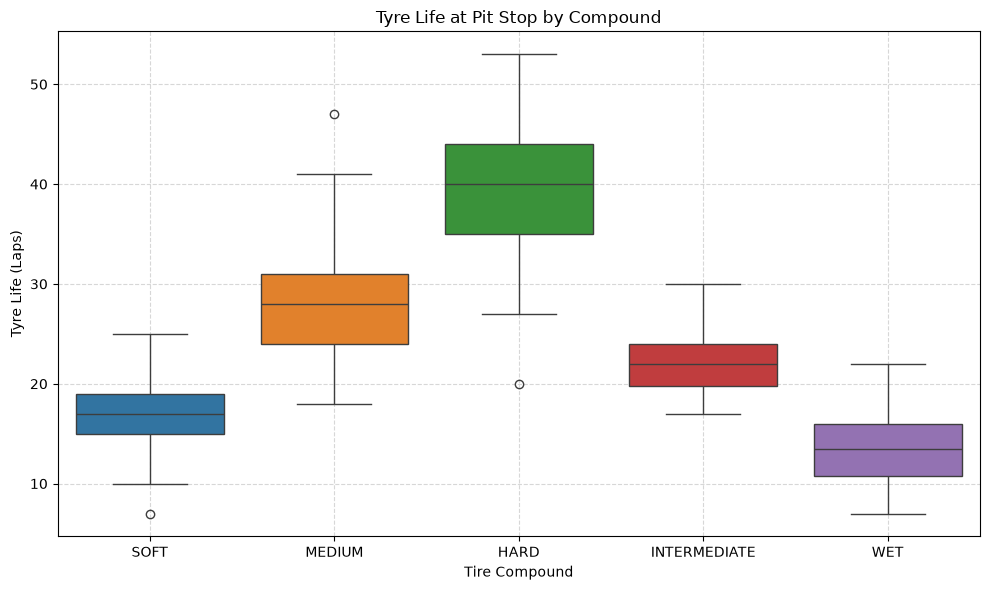

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Synthetic F1 dataset
np.random.seed(42)
compounds = ['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET']
data = []
for c in compounds:
    if c == 'SOFT':
        life = np.random.normal(18, 4, 100)
    elif c == 'MEDIUM':
        life = np.random.normal(28, 5, 120)
    elif c == 'HARD':
        life = np.random.normal(40, 6, 80)
    elif c == 'INTERMEDIATE':
        life = np.random.normal(22, 4, 40)
    else:
        life = np.random.normal(15, 5, 20)
    for l in life:
        data.append({'Compound': c, 'TyreLife': max(1, int(l)), 'PitNextLap': 1})

df_train = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_train[df_train["PitNextLap"] == 1], x="Compound", y="TyreLife", palette="tab10")
plt.title("Tyre Life at Pit Stop by Compound")
plt.xlabel("Tire Compound")
plt.ylabel("Tyre Life (Laps)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("tyre_life_distribution.png")
plt.show()

In [7]:
stats_by_stint_compound = (
    df_external
    .groupby(["Stint", "Compound"])["TyreLife"]
    .agg(
        Min="min",
        Mean="mean",
        Max="max",
        Median="median"
    )
    .reset_index()
)
print(stats_by_stint_compound)

    Stint      Compound   Min       Mean   Max  Median
0       1          HARD   1.0  18.737368  69.0    17.0
1       1  INTERMEDIATE   1.0  13.443161  44.0    12.0
2       1        MEDIUM   1.0  12.465672  55.0    11.0
3       1          SOFT   1.0  10.172764  44.0     9.0
4       1           WET   1.0   9.286667  21.0     9.0
5       2          HARD   1.0  17.462886  78.0    16.0
6       2  INTERMEDIATE   1.0  12.040205  39.0    10.0
7       2        MEDIUM   1.0  14.357051  77.0    13.0
8       2          SOFT   1.0  12.947050  39.0    12.0
9       2           WET   1.0   6.163934  18.0     5.0
10      3          HARD   1.0  14.523539  62.0    13.0
11      3  INTERMEDIATE   1.0  14.679374  41.0    13.0
12      3        MEDIUM   1.0  13.220874  59.0    12.0
13      3          SOFT   1.0  11.901794  50.0    11.0
14      3           WET   2.0   5.600000   9.0     5.0
15      4          HARD   1.0  14.987304  54.0    13.0
16      4  INTERMEDIATE   1.0  16.269537  35.0    16.0
17      4 

In [ ]:
print("No Pit Data")
print("Training dataset\n")

stats_by_compound = (
    df_train
    .groupby("Compound")["TyreLife"]
    .agg(
        Min ="min",
        Mean="mean",
        Max="max",
        Median="median"
    )
)

print(stats_by_compound)

print("\nExternal dataset\n")
stats_by_compound = (
    df_external
    .groupby("Compound")["TyreLife"]
    .agg(
        Min ="min",
        Mean="mean",
        Max="max",
        Median="median"
    )
)

print(stats_by_compound)

print("\nTrain merged dataset\n")
stats_by_compound = (
    df_train_merged
    .groupby("Compound")["TyreLife"]
    .agg(
        Min ="min",
        Mean="mean",
        Max="max",
        Median="median"
    )
)

print(stats_by_compound)

No Pit Data
Training dataset

              Min       Mean   Max  Median
Compound                                  
HARD          1.0  17.848441  77.0    17.0
INTERMEDIATE  1.0  13.228225  71.0    12.0
MEDIUM        1.0  11.830294  76.0    11.0
SOFT          1.0  11.180880  66.0    10.0
WET           1.0   9.579336  31.0     9.0

External dataset

              Min       Mean   Max  Median
Compound                                  
HARD          1.0  16.839549  78.0    15.0
INTERMEDIATE  1.0  13.345032  44.0    12.0
MEDIUM        1.0  13.179229  77.0    11.0
SOFT          1.0  11.188952  50.0    10.0
WET           1.0   8.616541  21.0     8.0

Train merged dataset

              Min       Mean   Max  Median
Compound                                  
HARD          1.0  17.637908  78.0    16.0
INTERMEDIATE  1.0  13.256518  71.0    12.0
MEDIUM        1.0  12.034380  77.0    11.0
SOFT          1.0  11.182878  66.0    10.0
WET           1.0   9.360319  31.0     8.0


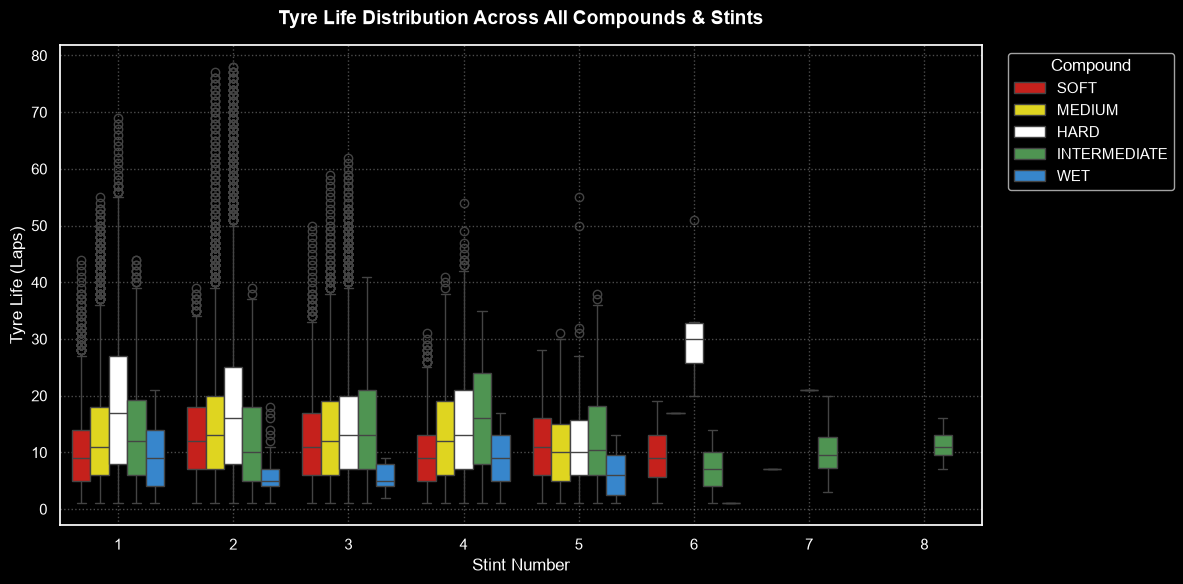

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# F1 compound color palette
f1_colors = {
    "SOFT": "#E10600",
    "MEDIUM": "#FFF200",
    "HARD": "#FFFFFF",
    "INTERMEDIATE": "#43A047",
    "WET": "#1E88E5",
}

# Dark theme layout
plt.style.use("dark_background")
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_external,
    x="Stint",
    y="TyreLife",
    hue="Compound",
    hue_order=["SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET"],
    palette=f1_colors,
)

plt.title(
    "Tyre Life Distribution Across All Compounds & Stints",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Stint Number", fontsize=12)
plt.ylabel("Tyre Life (Laps)", fontsize=12)
plt.legend(
    title="Compound", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True
)
plt.grid(True, linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()

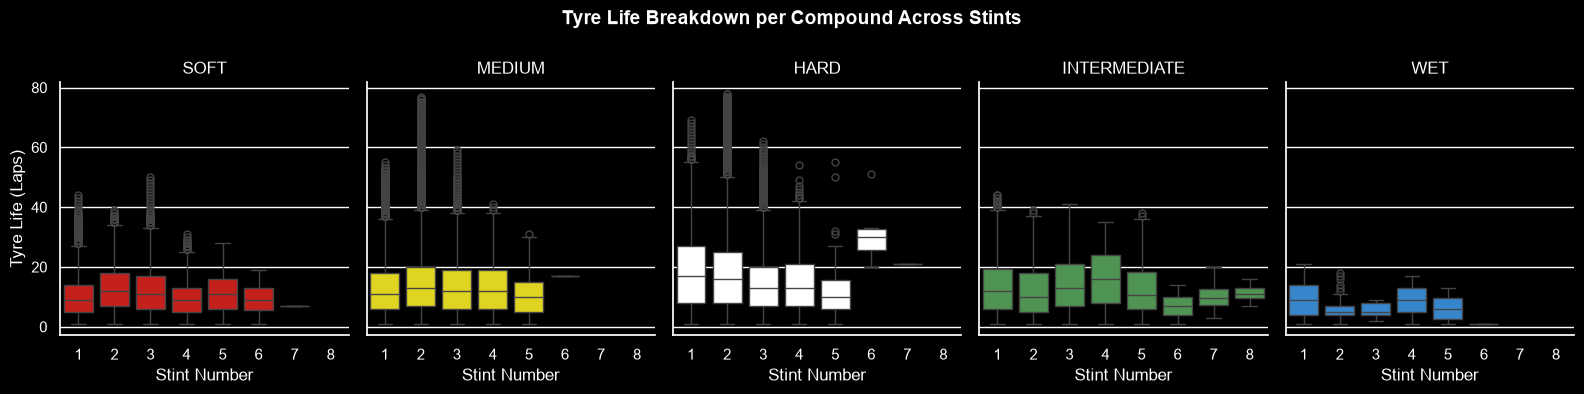

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.catplot(
    data=df_external,
    x="Stint",
    y="TyreLife",
    hue="Compound",  # Maps palette dictionary keys to Compound
    col="Compound",
    col_order=["SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET"],
    kind="box",
    height=4,
    aspect=0.8,
    palette=f1_colors,
    legend=False,  # Set to False since subplots are already split by Compound
)

g.set_axis_labels("Stint Number", "Tyre Life (Laps)")
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle(
    "Tyre Life Breakdown per Compound Across Stints",
    fontsize=14,
    fontweight="bold",
)
plt.show()

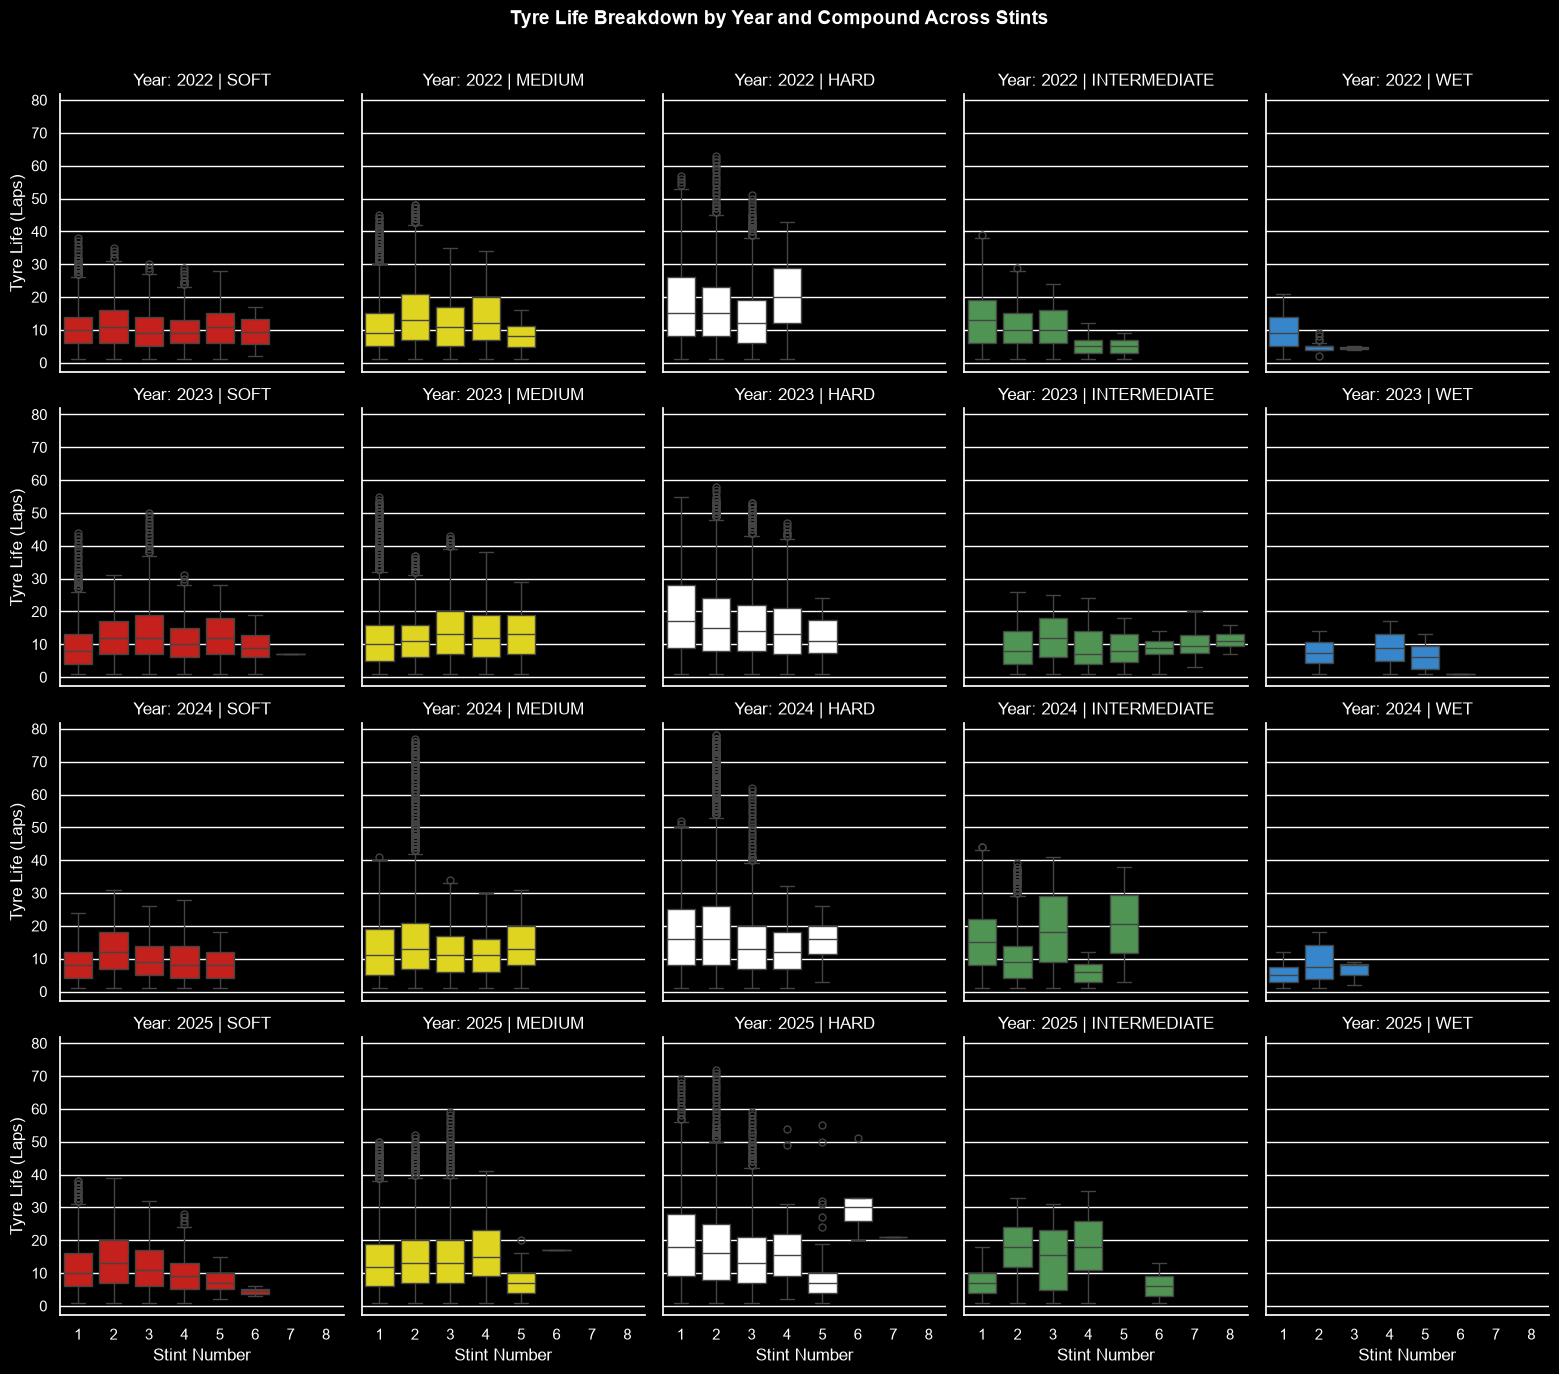

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.catplot(
    data=df_external,
    x="Stint",
    y="TyreLife",
    hue="Compound",
    col="Compound",
    row="Year",  # Adds Year as grid rows
    col_order=["SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET"],
    kind="box",
    height=3.5,
    aspect=0.9,
    palette=f1_colors,
    legend=False,
)

g.set_axis_labels("Stint Number", "Tyre Life (Laps)")
g.set_titles(col_template="{col_name}", row_template="Year: {row_name}")
g.fig.subplots_adjust(top=0.92)
g.fig.suptitle(
    "Tyre Life Breakdown by Year and Compound Across Stints",
    fontsize=14,
    fontweight="bold",
)
plt.show()

In [14]:
# Complete statistical aggregate for all stints and compounds
stats_all = (
    df_external.groupby(["Stint", "Compound"])["TyreLife"]
    .agg(
        Stint_Count="count",
        Mean_Life="mean",
        Median_Life="median",
        Min_Life="min",
        Max_Life="max",
        Std_Dev="std",
    )
    .reset_index()
)
stats_all

,Stint,Compound,Stint_Count,Mean_Life,Median_Life,Min_Life,Max_Life,Std_Dev
0,1,HARD,6610,18.737368,17.0,1.0,69.0,12.548445
1,1,INTERMEDIATE,2164,13.443161,12.0,1.0,44.0,9.084796
2,1,MEDIUM,18440,12.465672,11.0,1.0,55.0,8.805194
3,1,SOFT,4428,10.172764,9.0,1.0,44.0,6.773246
4,1,WET,300,9.286667,9.0,1.0,21.0,5.637709
5,2,HARD,25920,17.462886,16.0,1.0,78.0,11.864905
6,2,INTERMEDIATE,1368,12.040205,10.0,1.0,39.0,8.539027
7,2,MEDIUM,11679,14.357051,13.0,1.0,77.0,10.228680
8,2,SOFT,2644,12.947050,12.0,1.0,39.0,7.613254
9,2,WET,61,6.163934,5.0,1.0,18.0,3.620222


In [33]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [34]:
df_train.nunique()

id                        439140
Driver                       887
Compound                       5
Race                          26
Year                           4
PitStop                        2
LapNumber                     78
Stint                          8
TyreLife                      78
Position                      20
LapTime (s)                37719
LapTime_Delta              57532
Cumulative_Degradation    142701
RaceProgress                1898
Position_Change               37
PitNextLap                     2
dtype: int64

In [35]:
df_train.isnull().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

In [36]:
df_train.duplicated().sum()

np.int64(0)

In [37]:
Target = 'PitNextLap'
print(df_train[Target].value_counts())
print(df_external[Target].value_counts())

PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64
PitNextLap
0    75542
1    25829
Name: count, dtype: int64


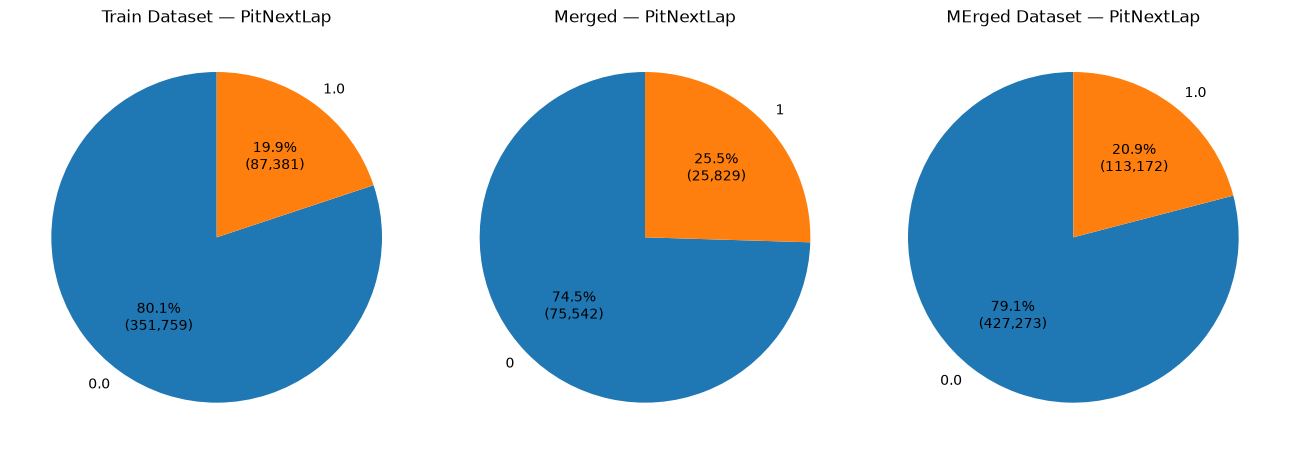

In [39]:
train_counts = df_train[Target].value_counts()
merged_train_counts = df_train_merged[Target].value_counts()
external_counts = df_external[Target].value_counts()

def make_autopct(values):
    def autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100))
        return f'{pct:.1f}%\n({count:,})'
    return autopct

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

axes[0].pie(
    train_counts.values,
    labels=train_counts.index,
    autopct=make_autopct(train_counts.values),
    startangle=90
)
axes[0].set_title(f'Train Dataset — {Target}')

axes[1].pie(
    external_counts.values,
    labels=external_counts.index,
    autopct=make_autopct(external_counts.values),
    startangle=90
)
axes[1].set_title(f'Merged — {Target}')

axes[2].pie(
    merged_train_counts.values,
    labels=merged_train_counts.index,
    autopct=make_autopct(merged_train_counts.values),
    startangle=90
)
axes[2].set_title(f'MErged Dataset — {Target}')


plt.tight_layout()
plt.show()

In [11]:

numerical_features = ['LapNumber', 'TyreLife', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress']
categorical_features = ['Year', 'PitStop', 'Stint', 'Position']
obj_categorical_features = ['Compound', 'Race', 'Driver']

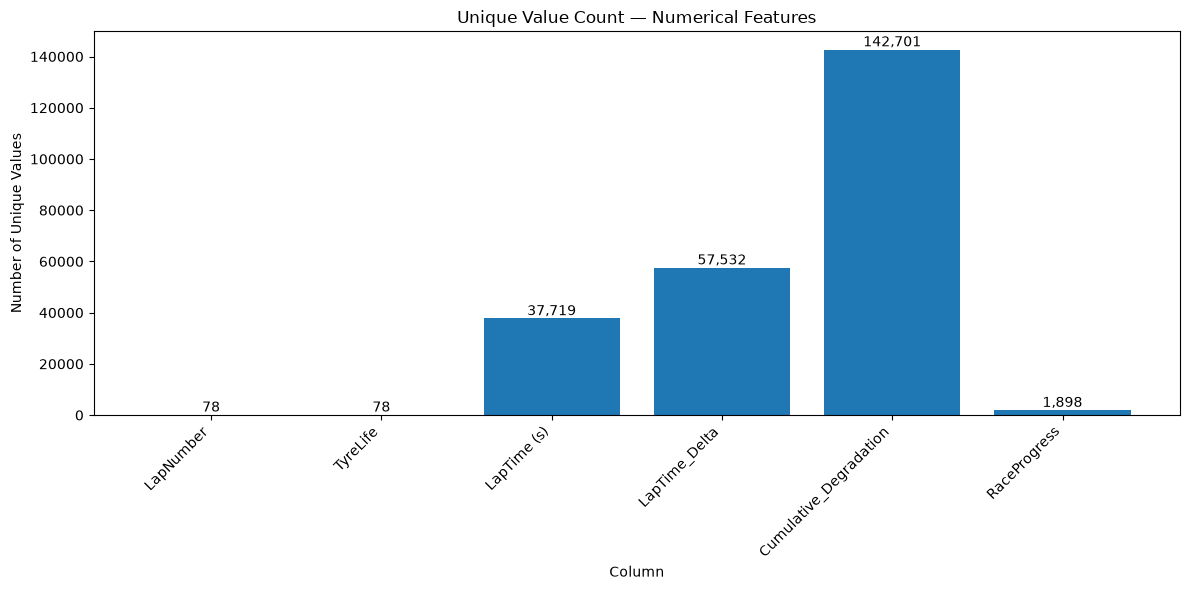

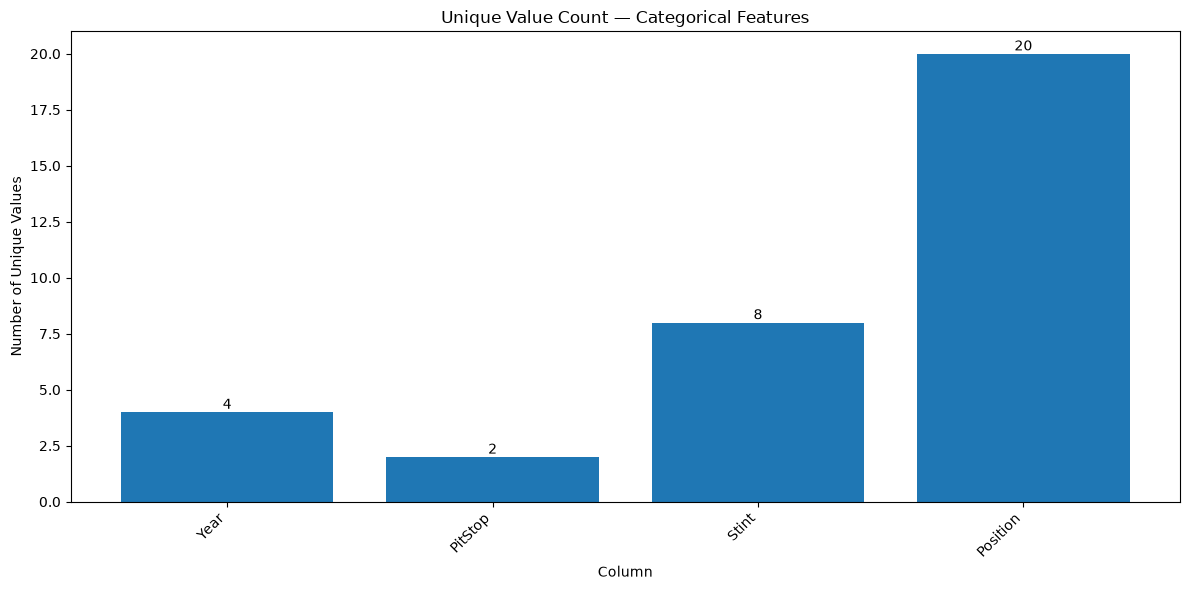

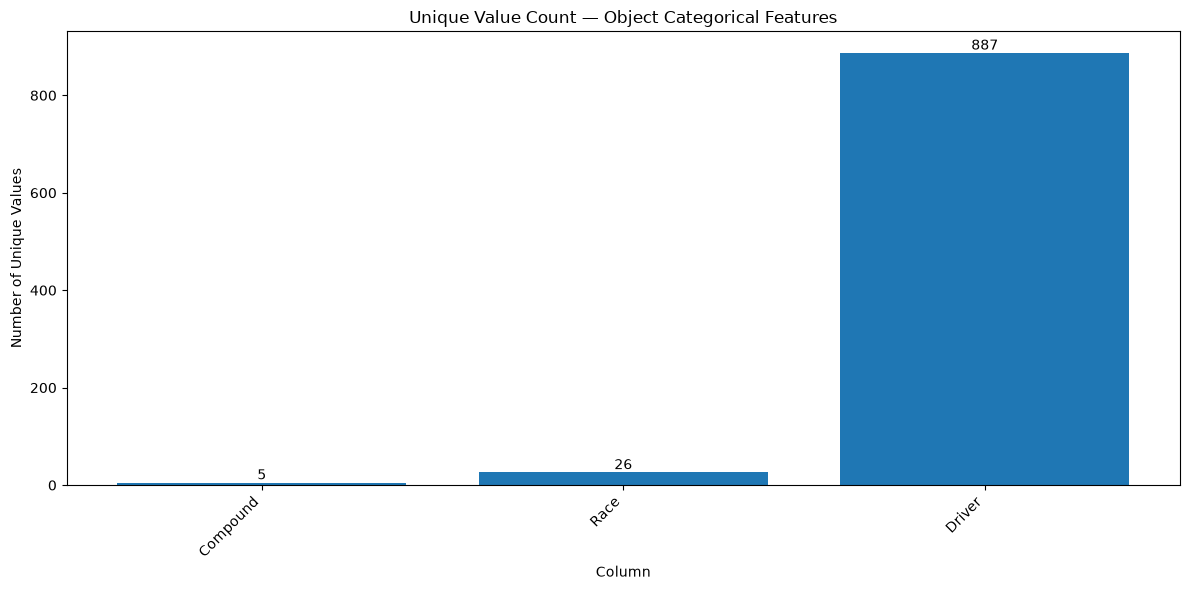

In [12]:
import matplotlib.pyplot as plt

numerical_features = [
    'LapNumber',
    'TyreLife',
    'LapTime (s)',
    'LapTime_Delta',
    'Cumulative_Degradation',
    'RaceProgress'
]

categorical_features = [
    'Year',
    'PitStop',
    'Stint',
    'Position'
]

obj_categorical_features = [
    'Compound',
    'Race',
    'Driver'
]


def plot_unique_counts(features, title):
    unique_counts = df_train[features].nunique()

    plt.figure(figsize=(12, 6))

    bars = plt.bar(
        unique_counts.index,
        unique_counts.values
    )

    plt.title(title)
    plt.xlabel('Column')
    plt.ylabel('Number of Unique Values')
    plt.xticks(rotation=45, ha='right')

    # Add values on top of bars
    for bar, value in zip(bars, unique_counts.values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{value:,}',
            ha='center',
            va='bottom'
        )

    plt.tight_layout()
    plt.show()


# 1. Numerical features
plot_unique_counts(
    numerical_features,
    'Unique Value Count — Numerical Features'
)

# 2. Categorical features
plot_unique_counts(
    categorical_features,
    'Unique Value Count — Categorical Features'
)

# 3. Object categorical features
plot_unique_counts(
    obj_categorical_features,
    'Unique Value Count — Object Categorical Features'
)

In [13]:
print("Drivers in original : ",df_external['Driver'].unique(), "\nOriginal Driver names : ", len(df_external['Driver'].unique()))
print("Drivers in Train : ",df_train['Driver'].unique(), "\nTrain  Driver names : ", len(df_train['Driver'].unique()))
print("Drivers in Train : ",df_train[~df_train['Driver'].str.startswith('D')]['Driver'].unique(), "\nTrain  Driver names : ", len(df_train[~df_train['Driver'].str.startswith('D')]['Driver'].unique()))

# conclusions here : Drivers columns are not required

Drivers in original :  ['ALB' 'ALO' 'BOT' 'GAS' 'HAM' 'HUL' 'LEC' 'MAG' 'NOR' 'OCO' 'PER' 'PIA'
 'RIC' 'RUS' 'SAI' 'SAR' 'STR' 'TSU' 'VER' 'ZHO' 'DEV' 'LAW' 'COL' 'DOO'
 'BEA' 'ANT' 'BOR' 'HAD' 'LAT' 'MSC' 'VET'] 
Original Driver names :  31
Drivers in Train :  ['D109' 'D086' 'ZON' 'SPE' 'D019' 'D012' 'D104' 'D082' 'BEL' 'YAM' 'MAS'
 'D010' 'D063' 'D196' 'D132' 'D047' 'PRO' 'D066' 'DRA' 'PEA' 'HAD' 'HUL'
 'COU' 'D036' 'D205' 'BER' 'VIL' 'GUT' 'TUR' 'D089' 'D055' 'D189' 'D071'
 'DAM' 'D144' 'D384' 'D263' 'D117' 'D120' 'D054' 'D184' 'D214' 'IDE'
 'D216' 'D101' 'D160' 'WIL' 'CAR' 'D251' 'D106' 'D083' 'WAR' 'D065' 'MIN'
 'D293' 'BIA' 'D125' 'D073' 'ALE' 'D007' 'D009' 'D202' 'NOR' 'FRE' 'D057'
 'D177' 'D049' 'ALG' 'SUT' 'D312' 'D159' 'D219' 'ROS' 'D166' 'D218' 'D045'
 'D197' 'GIO' 'DIR' 'D138' 'WEB' 'D070' 'D097' 'LEC' 'D050' 'D369' 'HYD'
 'D355' 'D032' 'D292' 'BEA' 'D001' 'D232' 'D211' 'DIN' 'D157' 'NAK' 'TAY'
 'STR' 'D325' 'D028' 'RIC' 'ZHO' 'GAS' 'D041' 'D014' 'D283' 'WUR' 'D061'
 'D281'

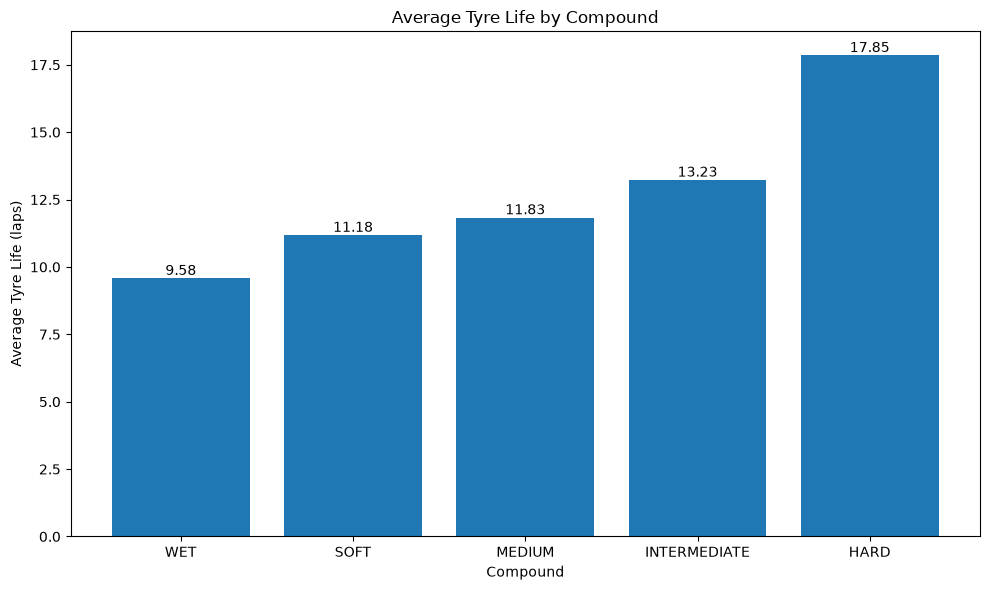

In [14]:
plt.figure(figsize=(10, 6))

avg_tyre_life = df_train.groupby('Compound')['TyreLife'].mean().sort_values()

bars = plt.bar(
    avg_tyre_life.index,
    avg_tyre_life.values
)

plt.title('Average Tyre Life by Compound')
plt.xlabel('Compound')
plt.ylabel('Average Tyre Life (laps)')

for bar, value in zip(bars, avg_tyre_life.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:.2f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

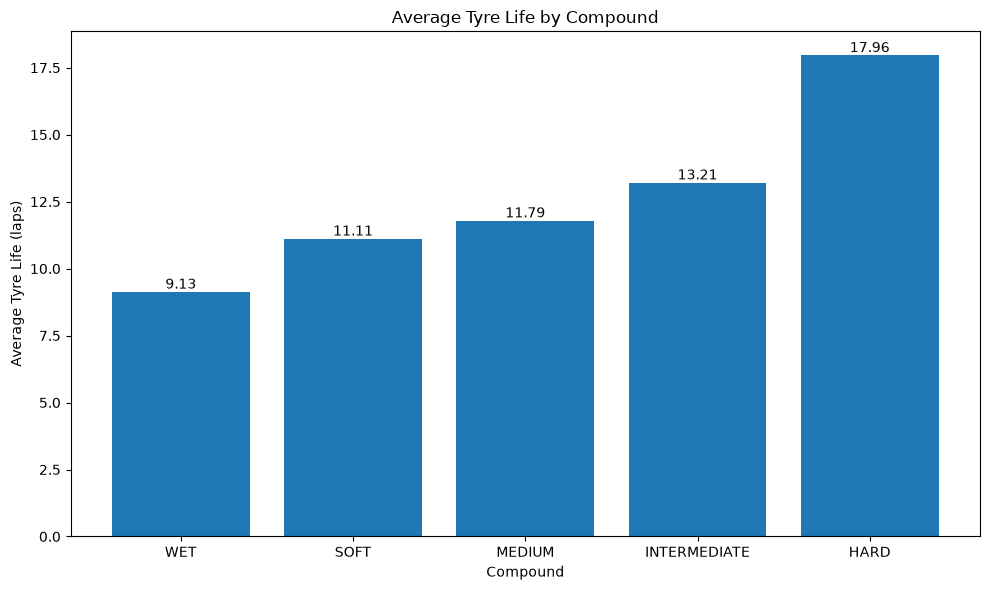

In [15]:
plt.figure(figsize=(10, 6))

avg_tyre_life = df_test.groupby('Compound')['TyreLife'].mean().sort_values()

bars = plt.bar(
    avg_tyre_life.index,
    avg_tyre_life.values
)

plt.title('Average Tyre Life by Compound')
plt.xlabel('Compound')
plt.ylabel('Average Tyre Life (laps)')

for bar, value in zip(bars, avg_tyre_life.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:.2f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

## Train vs Test

In [16]:
from scipy.stats import ks_2samp

results = []

for col in numerical_features:

    train = df_train[col].dropna()
    test = df_test[col].dropna()

    ks_stat, p_value = ks_2samp(train, test)

    results.append({
        'Feature': col,
        'KS Statistic': ks_stat,
        'P-Value': p_value,
        'Distribution Shift': 'YES' if p_value < 0.05 else 'NO'
    })

ks_results = pd.DataFrame(results)

ks_results.sort_values(
    'KS Statistic',
    ascending=False
)

,Feature,KS Statistic,P-Value,Distribution Shift
0,LapNumber,0.003243,0.124895,NO
5,RaceProgress,0.003111,0.155888,NO
1,TyreLife,0.002902,0.216857,NO
3,LapTime_Delta,0.002897,0.218381,NO
4,Cumulative_Degradation,0.002768,0.264694,NO
2,LapTime (s),0.001506,0.925584,NO


In [17]:
comparison = []

for col in numerical_features:

    train = df_train[col].dropna()
    test = df_test[col].dropna()

    comparison.append({
        'Feature': col,

        'Train Mean': train.mean(),
        'Test Mean': test.mean(),

        'Train Std': train.std(),
        'Test Std': test.std(),

        'Train Median': train.median(),
        'Test Median': test.median(),

        'Train Min': train.min(),
        'Test Min': test.min(),

        'Train Max': train.max(),
        'Test Max': test.max(),

        'Train Missing %': df_train[col].isna().mean() * 100,
        'Test Missing %': df_test[col].isna().mean() * 100
    })

distribution_comparison = pd.DataFrame(comparison)

distribution_comparison

,Feature,Train Mean,Test Mean,Train Std,Test Std,Train Median,Test Median,Train Min,Test Min,Train Max,Test Max,Train Missing %,Test Missing %
0,LapNumber,23.105909,23.050185,16.958261,17.002292,19.000000,19.000000,1.000000,1.000000,78.000,77.000,0.0,0.0
1,TyreLife,14.158231,14.160625,9.801338,9.852778,12.000000,12.000000,1.000000,1.000000,77.000,77.000,0.0,0.0
2,LapTime (s),90.948735,90.986869,19.772769,20.855248,90.521000,90.485000,67.694000,67.017000,2507.607,2497.905,0.0,0.0
3,LapTime_Delta,-3.770040,-3.577802,43.945759,40.348466,-0.295000,-0.285000,-2403.895000,-2403.216000,2423.932,2433.472,0.0,0.0
4,Cumulative_Degradation,-25.721759,-25.849491,54.766573,54.920269,-20.994000,-21.027000,-274.564000,-274.564000,2412.026,2406.800,0.0,0.0
5,RaceProgress,0.337661,0.336695,0.253277,0.253396,0.269231,0.269231,0.012821,0.012821,1.000,1.000,0.0,0.0


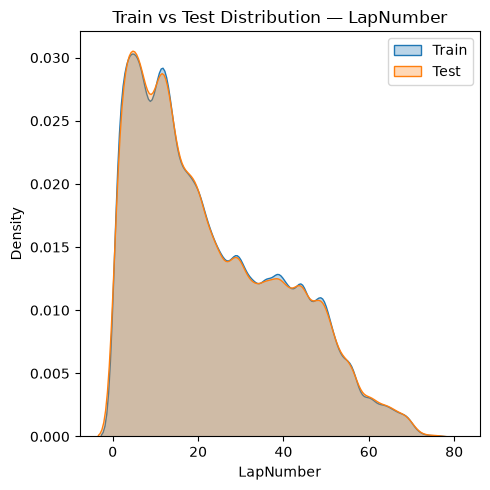

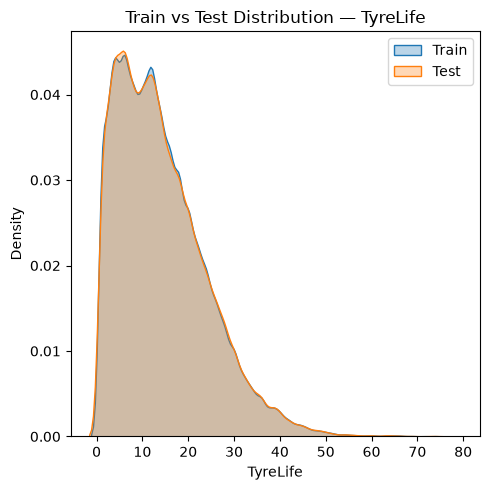

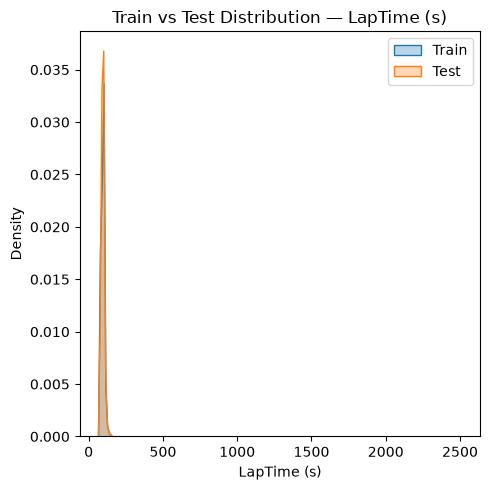

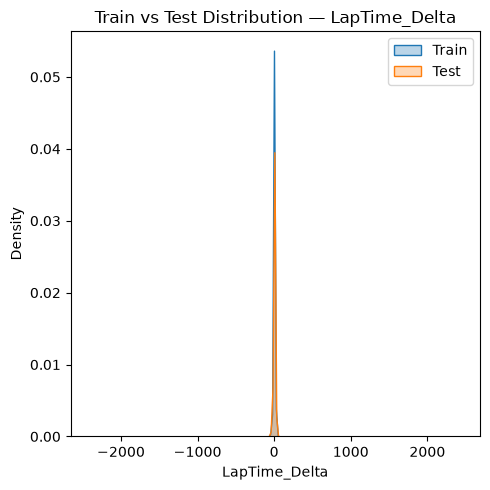

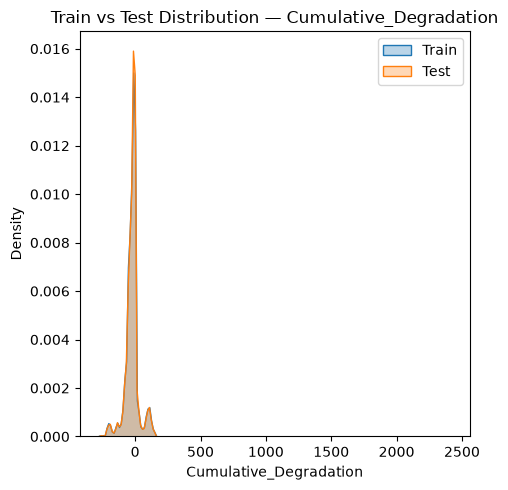

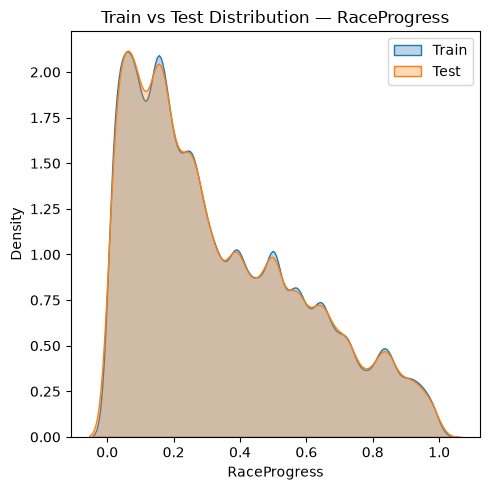

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_features:

    plt.figure(figsize=(5,5))

    sns.kdeplot(
        df_train[col].dropna(),
        label='Train',
        fill=True,
        alpha=0.3
    )

    sns.kdeplot(
        df_test[col].dropna(),
        label='Test',
        fill=True,
        alpha=0.3
    )

    plt.title(f'Train vs Test Distribution — {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()

    plt.tight_layout()
    plt.show()

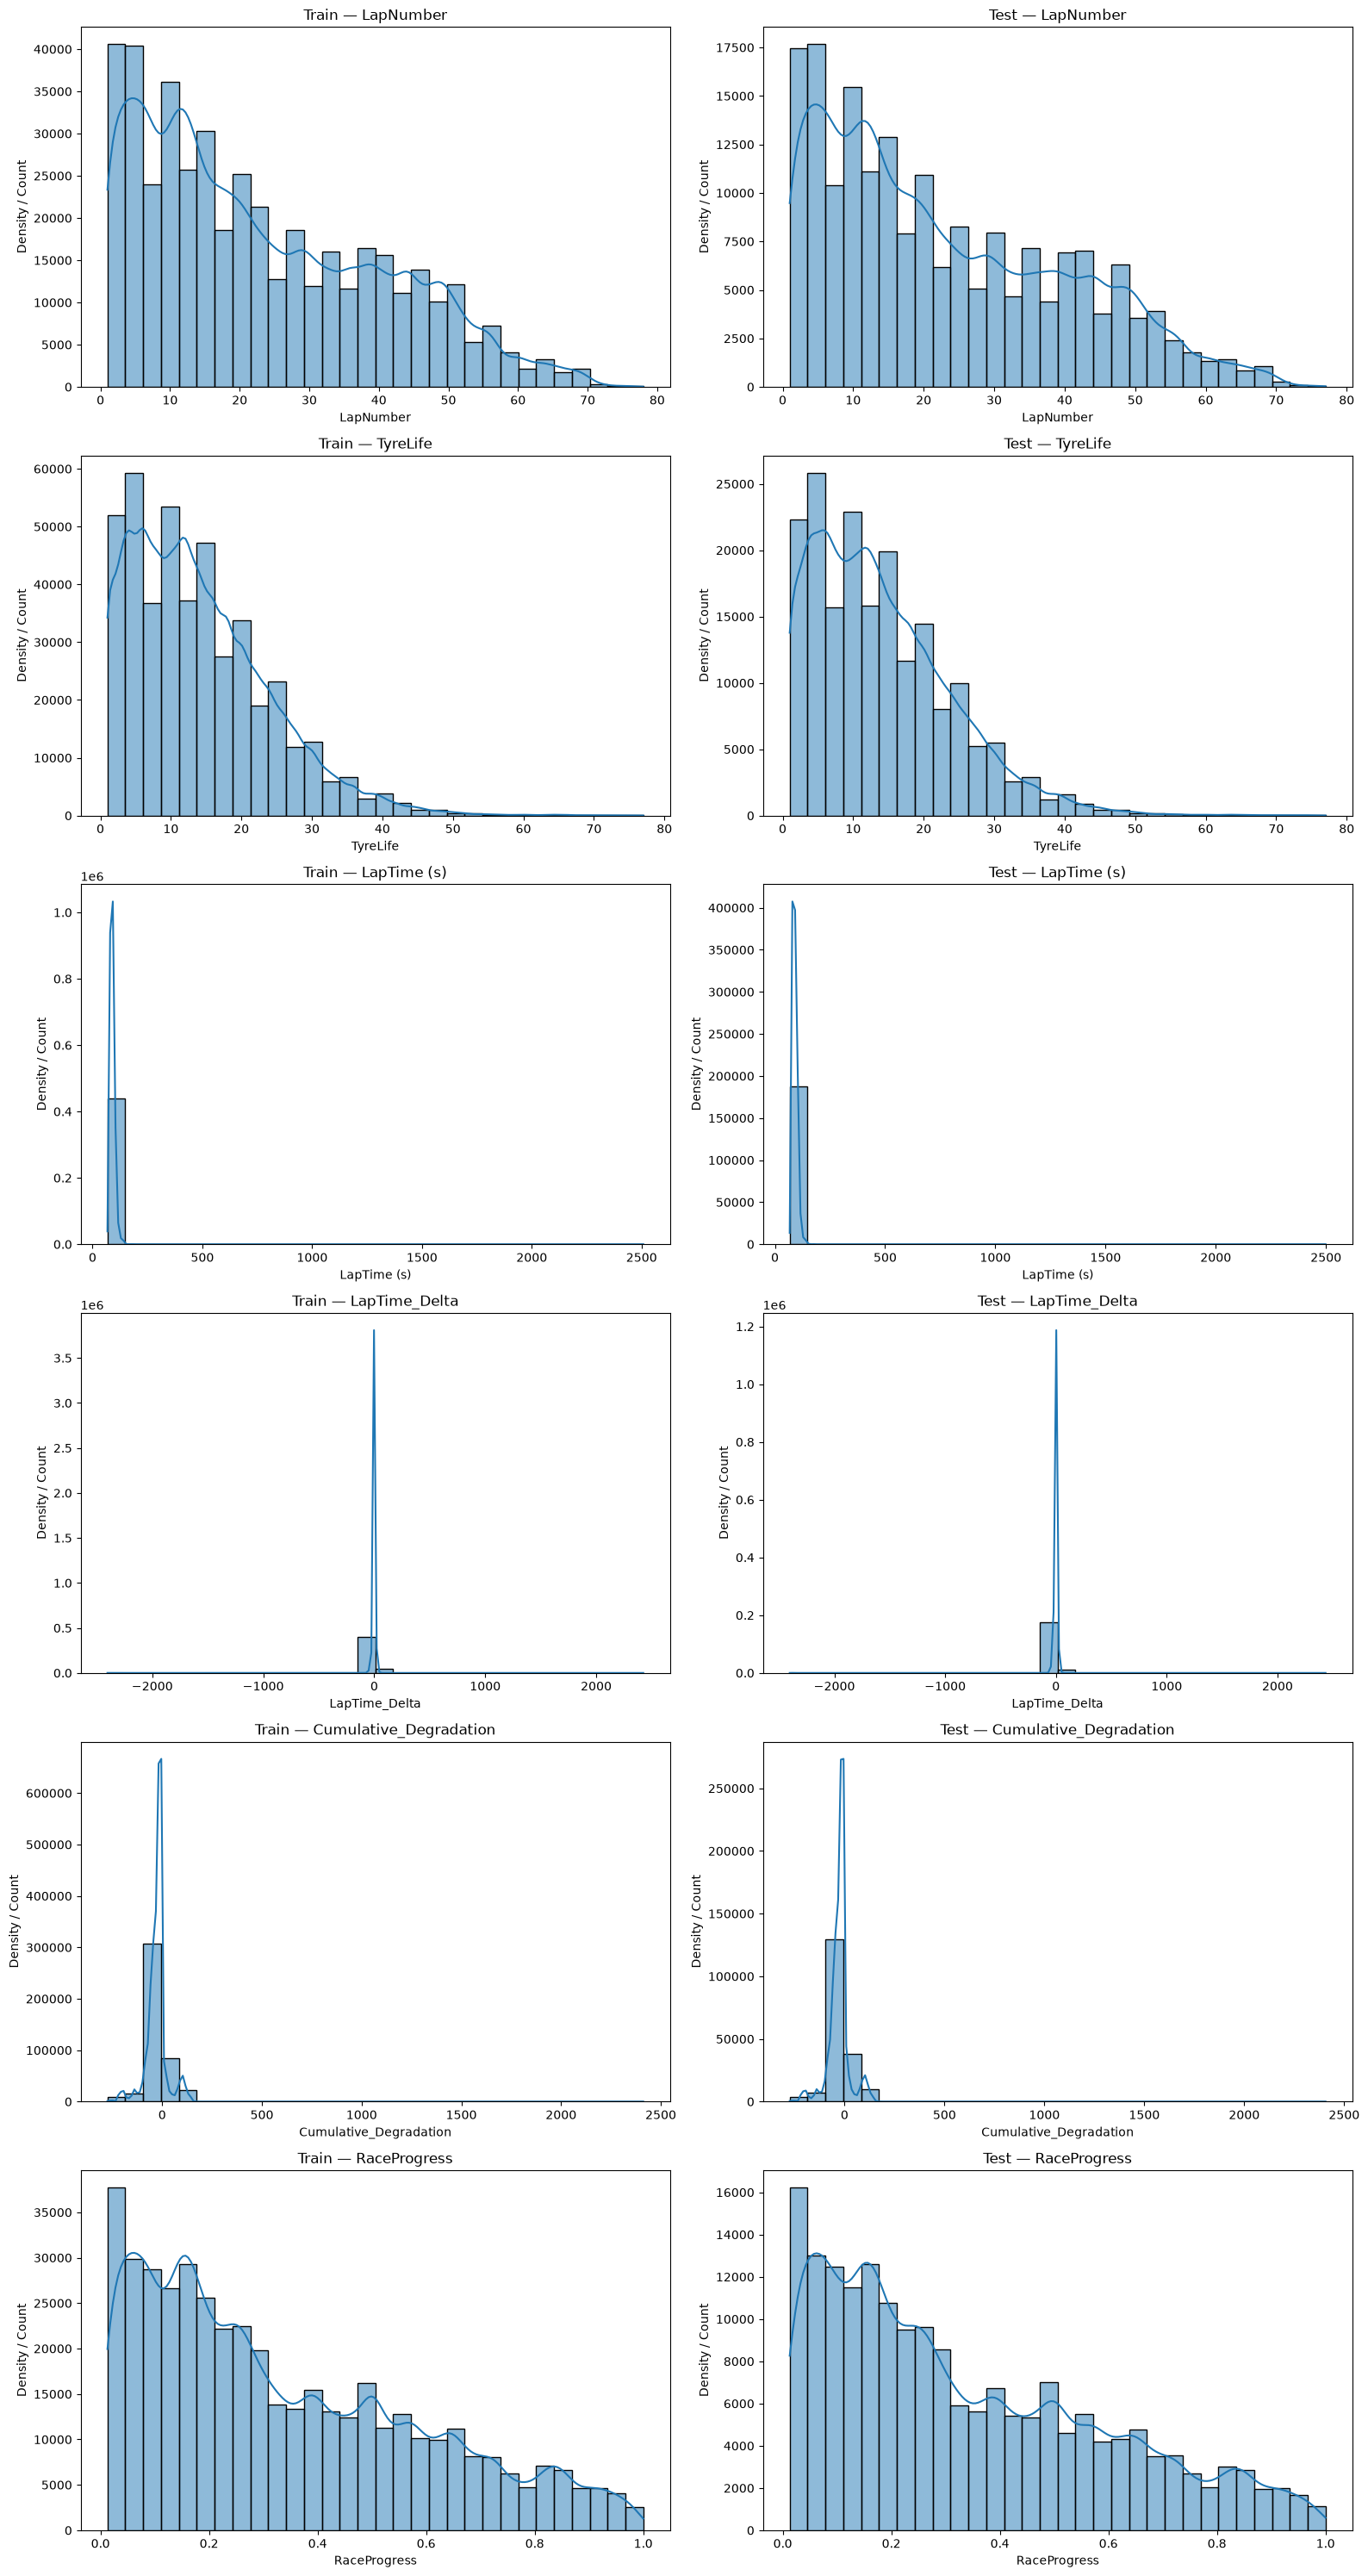

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features = [
    'LapNumber',
    'TyreLife',
    'LapTime (s)',
    'LapTime_Delta',
    'Cumulative_Degradation',
    'RaceProgress'
]

fig, axes = plt.subplots(
    len(numerical_features),
    2,
    figsize=(16, 5 * len(numerical_features))
)

for i, col in enumerate(numerical_features):

    # Train
    sns.histplot(
        df_train[col].dropna(),
        bins=30,
        kde=True,
        ax=axes[i, 0]
    )

    axes[i, 0].set_title(f'Train — {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Density / Count')

    # Test
    sns.histplot(
        df_test[col].dropna(),
        bins=30,
        kde=True,
        ax=axes[i, 1]
    )

    axes[i, 1].set_title(f'Test — {col}')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('Density / Count')

plt.tight_layout()
plt.show()

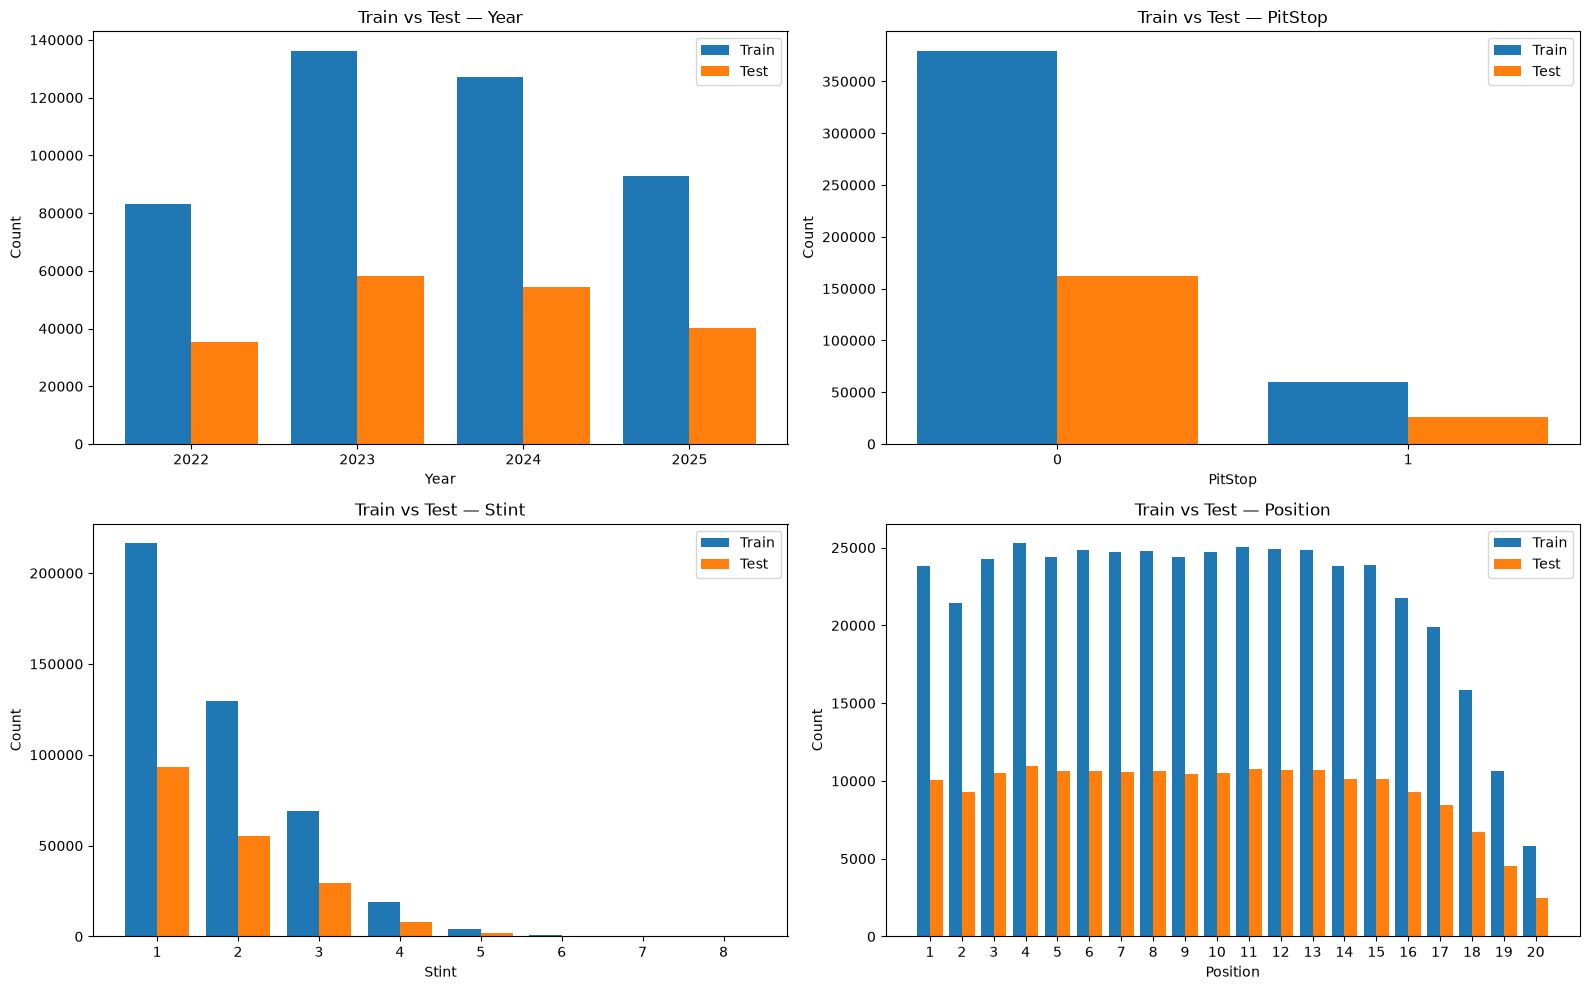

In [20]:
import matplotlib.pyplot as plt

categorical_features = [
    'Year',
    'PitStop',
    'Stint',
    'Position'
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10)
)

axes = axes.flatten()

for i, col in enumerate(categorical_features):

    # Keep integer categories
    train_counts = df_train[col].value_counts().sort_index()
    test_counts = df_test[col].value_counts().sort_index()

    # All integer categories from both datasets
    categories = sorted(
        set(train_counts.index) |
        set(test_counts.index)
    )

    train_values = [
        train_counts.get(x, 0)
        for x in categories
    ]

    test_values = [
        test_counts.get(x, 0)
        for x in categories
    ]

    # Bar positions
    x = range(len(categories))
    width = 0.4

    axes[i].bar(
        [p - width / 2 for p in x],
        train_values,
        width=width,
        label='Train'
    )

    axes[i].bar(
        [p + width / 2 for p in x],
        test_values,
        width=width,
        label='Test'
    )

    axes[i].set_title(f'Train vs Test — {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

    # Keep original integer values
    axes[i].set_xticks(list(x))
    axes[i].set_xticklabels(categories)

    axes[i].legend()

plt.tight_layout()
plt.show()

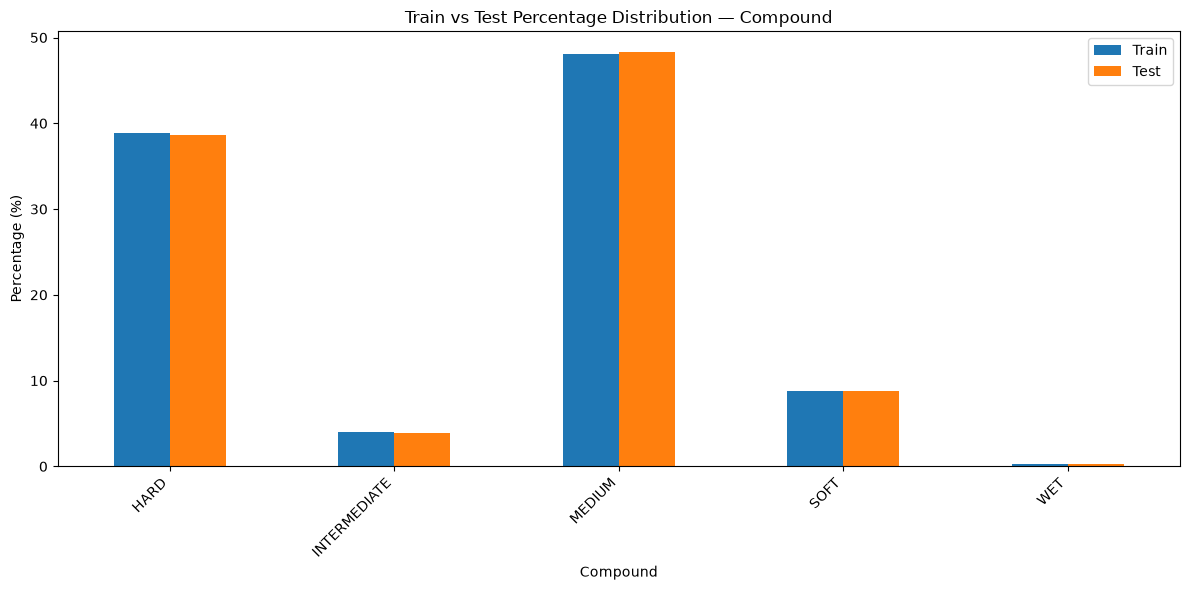

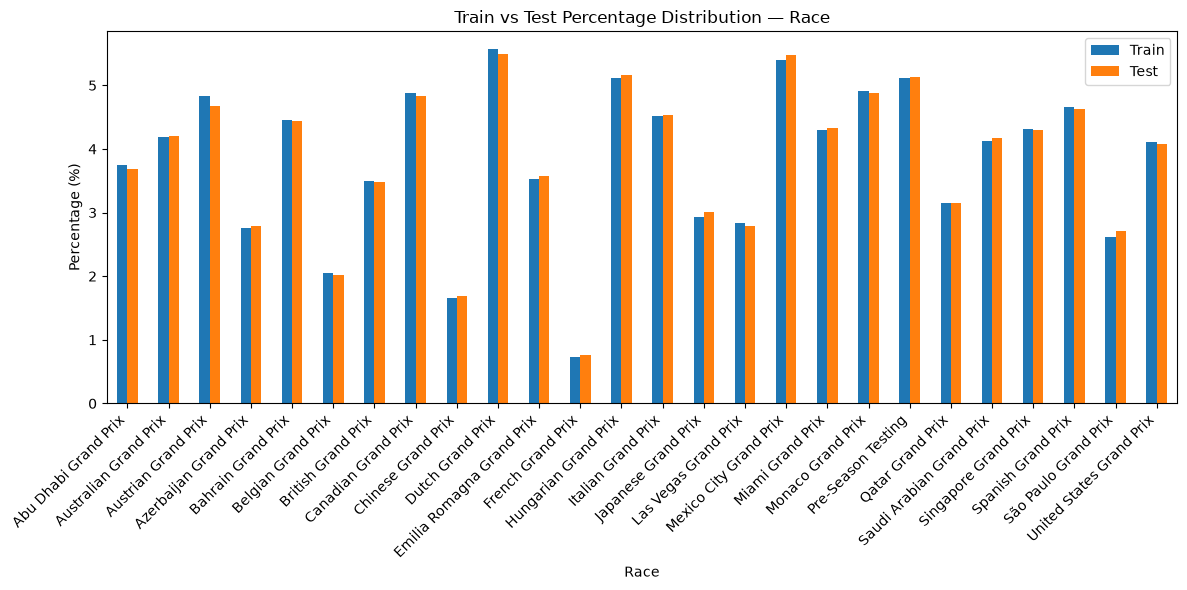

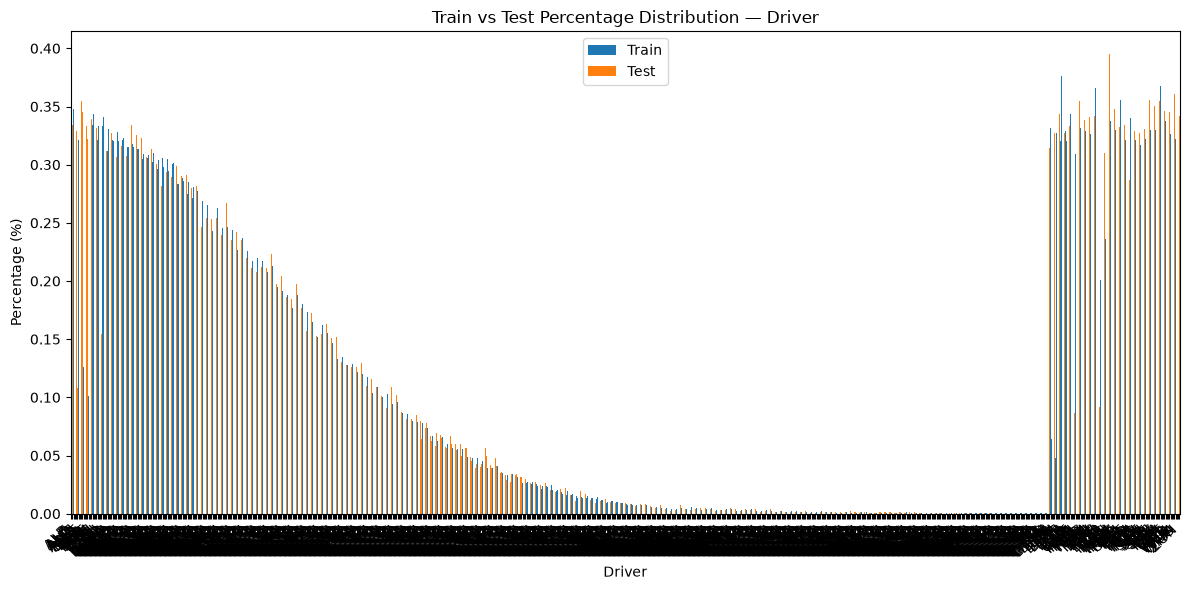

In [21]:
for col in  obj_categorical_features:

    train_pct = (
        df_train[col]
        .value_counts(normalize=True)
        .mul(100)
    )

    test_pct = (
        df_test[col]
        .value_counts(normalize=True)
        .mul(100)
    )

    categories = sorted(
        set(train_pct.index) | set(test_pct.index)
    )

    comparison = pd.DataFrame({
        'Train': train_pct.reindex(categories, fill_value=0),
        'Test': test_pct.reindex(categories, fill_value=0)
    })

    comparison.plot(
        kind='bar',
        figsize=(12, 6)
    )

    plt.title(f'Train vs Test Percentage Distribution — {col}')
    plt.xlabel(col)
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45, ha='right')
    plt.legend()

    plt.tight_layout()
    plt.show()

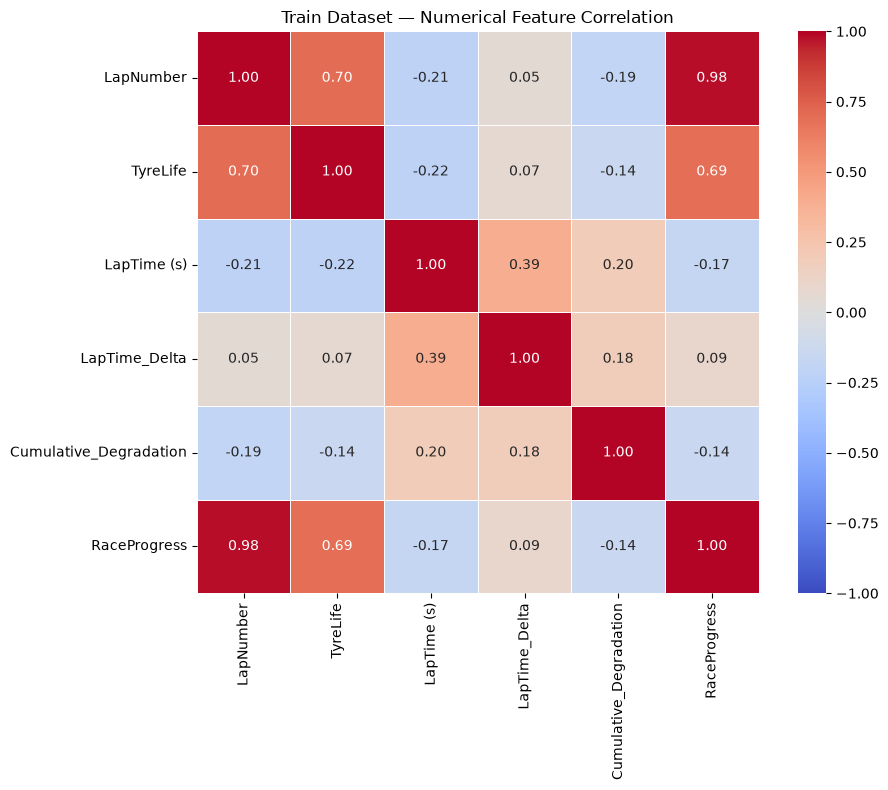

In [22]:

import seaborn as sns

numerical_features = [
    'LapNumber',
    'TyreLife',
    'LapTime (s)',
    'LapTime_Delta',
    'Cumulative_Degradation',
    'RaceProgress'
]

train_corr = df_train[numerical_features].corr(method='spearman')

plt.figure(figsize=(10, 8))

sns.heatmap(
    train_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title('Train Dataset — Numerical Feature Correlation')
plt.tight_layout()
plt.show()

In [23]:
plt.figure(figsize=(12, 6))

plot_data = correlation_metrics.sort_values(
    'Spearman',
    ascending=True
)

sns.barplot(
    data=plot_data,
    x='Spearman',
    y='Feature'
)

plt.axvline(0, linewidth=1)

plt.title('Numerical Feature Correlation with PitNextLap')
plt.xlabel('Spearman Correlation')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

NameError: name 'correlation_metrics' is not defined

<Figure size 1200x600 with 0 Axes>

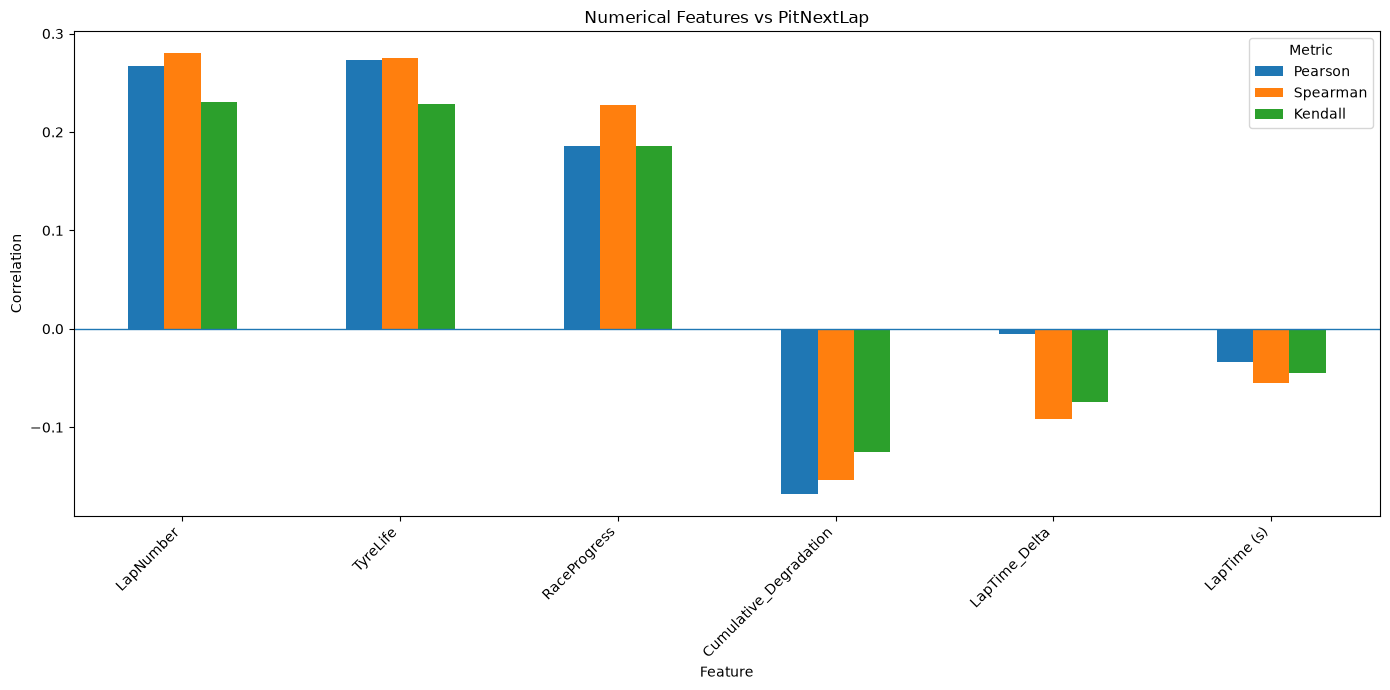

In [ ]:
plot_data = correlation_metrics.set_index('Feature')

plot_data[['Pearson', 'Spearman', 'Kendall']].plot(
    kind='bar',
    figsize=(14, 7)
)

plt.axhline(0, linewidth=1)
plt.title('Numerical Features vs PitNextLap')
plt.xlabel('Feature')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')

plt.tight_layout()
plt.show()

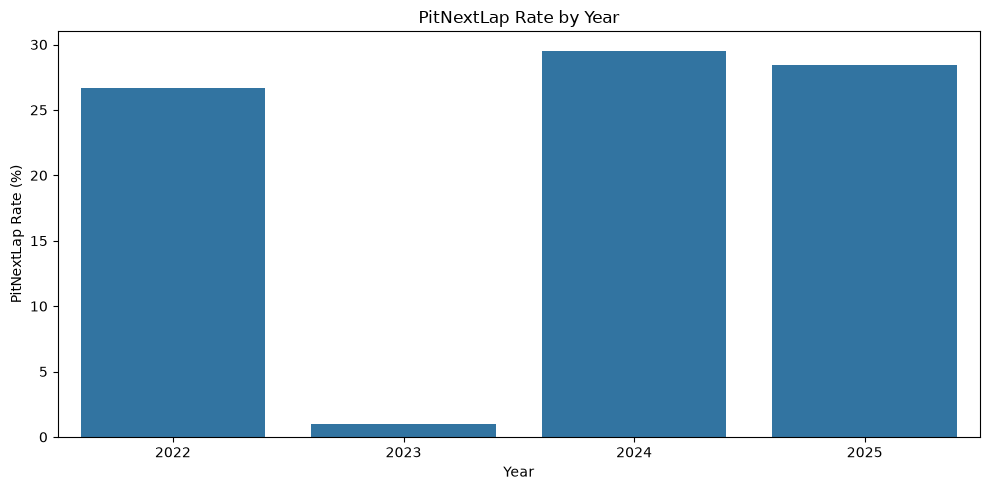

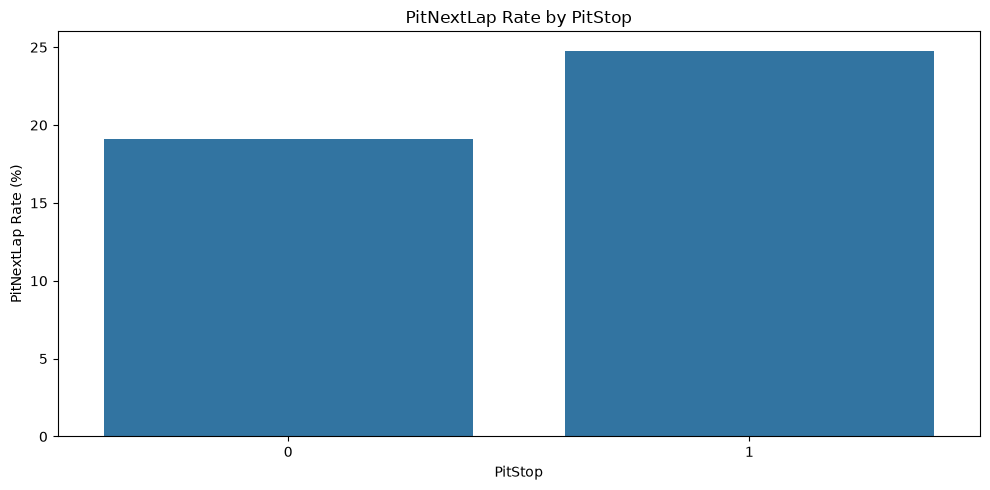

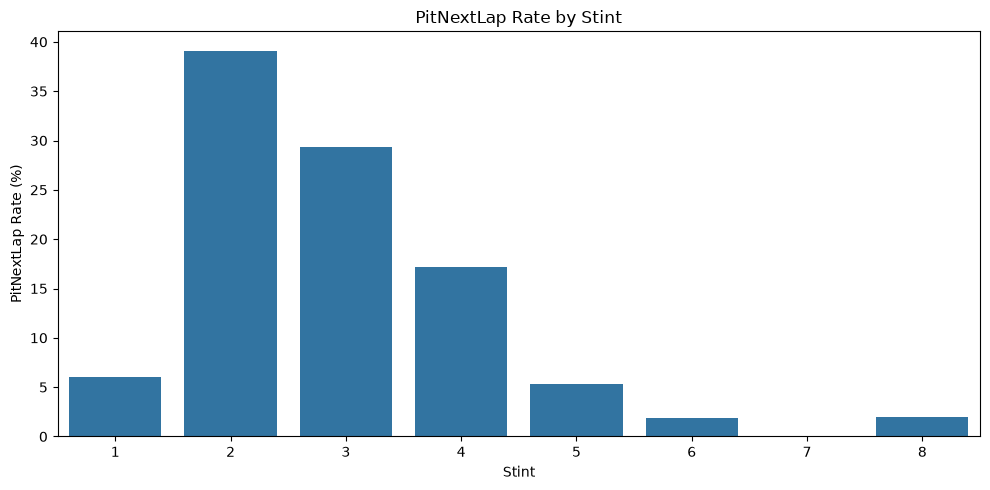

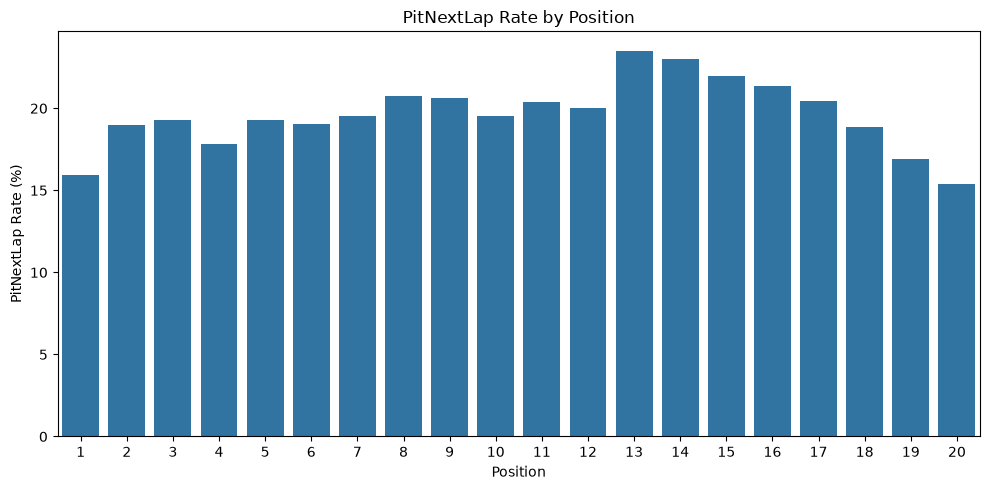

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

for col in categorical_features:

    target_rate = (
        df_train
        .groupby(col)[Target]
        .mean()
        .mul(100)
        .reset_index()
    )

    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=target_rate,
        x=col,
        y=Target
    )

    plt.title(f'{Target} Rate by {col}')
    plt.xlabel(col)
    plt.ylabel(f'{Target} Rate (%)')

    plt.tight_layout()
    plt.show()

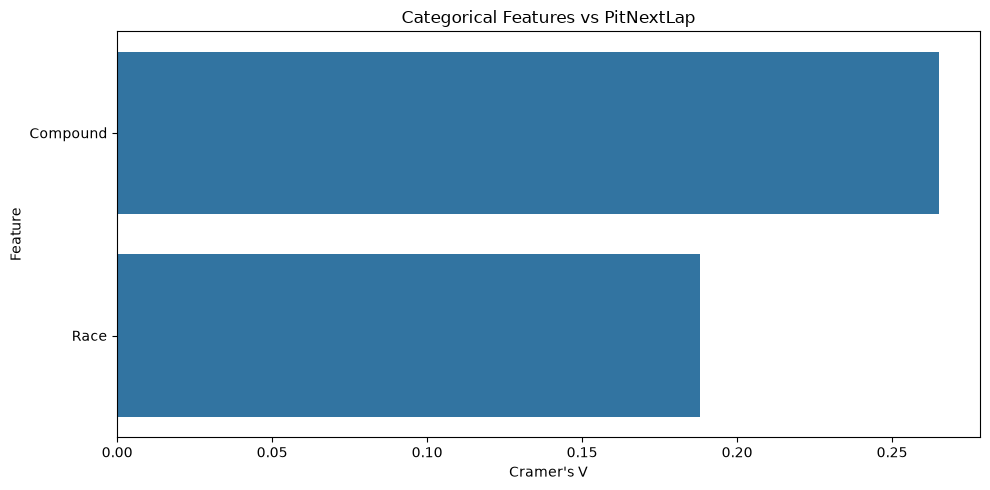

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=categorical_metrics,
    x="Cramer's V",
    y="Feature"
)

plt.title("Categorical Features vs PitNextLap")
plt.xlabel("Cramer's V")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

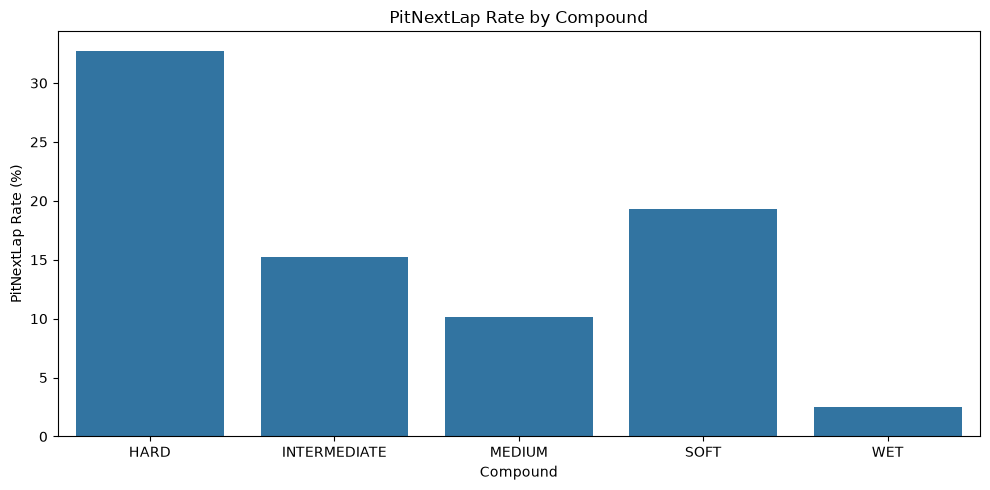

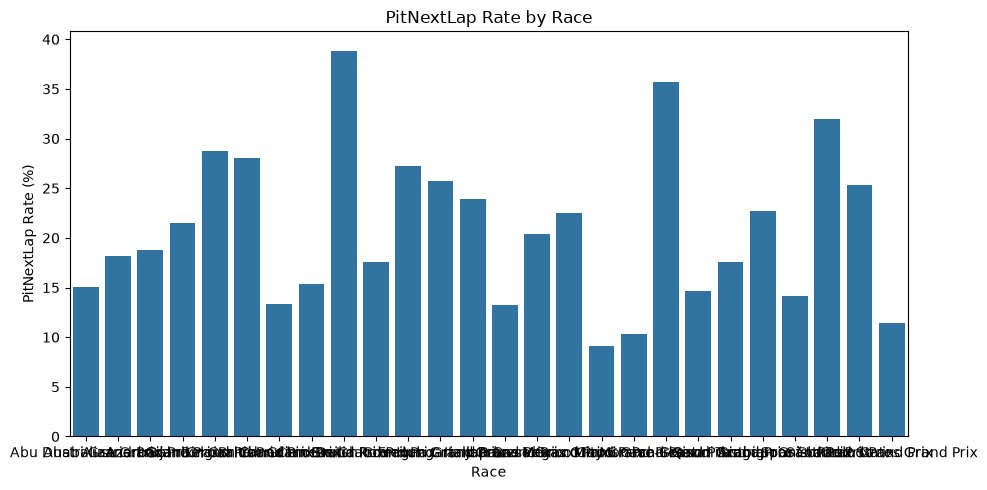

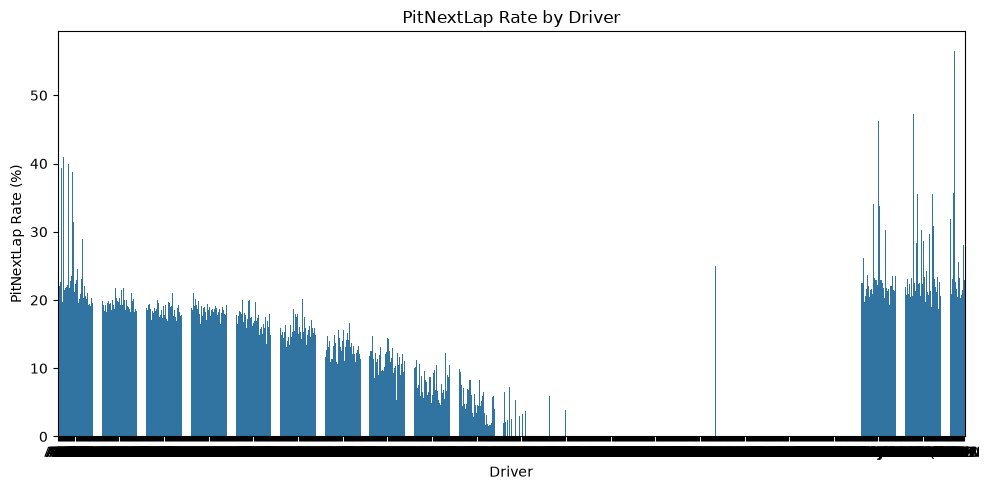

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

for col in obj_categorical_features:

    target_rate = (
        df_train
        .groupby(col)[Target]
        .mean()
        .mul(100)
        .reset_index()
    )

    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=target_rate,
        x=col,
        y=Target
    )

    plt.title(f'{Target} Rate by {col}')
    plt.xlabel(col)
    plt.ylabel(f'{Target} Rate (%)')

    plt.tight_layout()
    plt.show()

In [89]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):

    confusion_matrix = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion_matrix)[0]

    n = confusion_matrix.sum().sum()

    phi2 = chi2 / n

    r, k = confusion_matrix.shape

    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    return np.sqrt(
        phi2corr / min(kcorr - 1, rcorr - 1)
    )


results = []

for col in obj_categorical_features:

    value = cramers_v(
        df_train[col],
        df_train[Target]
    )

    results.append({
        'Feature': col,
        "Cramer's V": value
    })

obj_categorical_metrics = pd.DataFrame(results)

obj_categorical_metrics = obj_categorical_metrics.sort_values(
    "Cramer's V",
    ascending=False
)

display(obj_categorical_metrics)

,Feature,Cramer's V
0,Compound,0.265102
1,Race,0.187999
2,Driver,0.127482


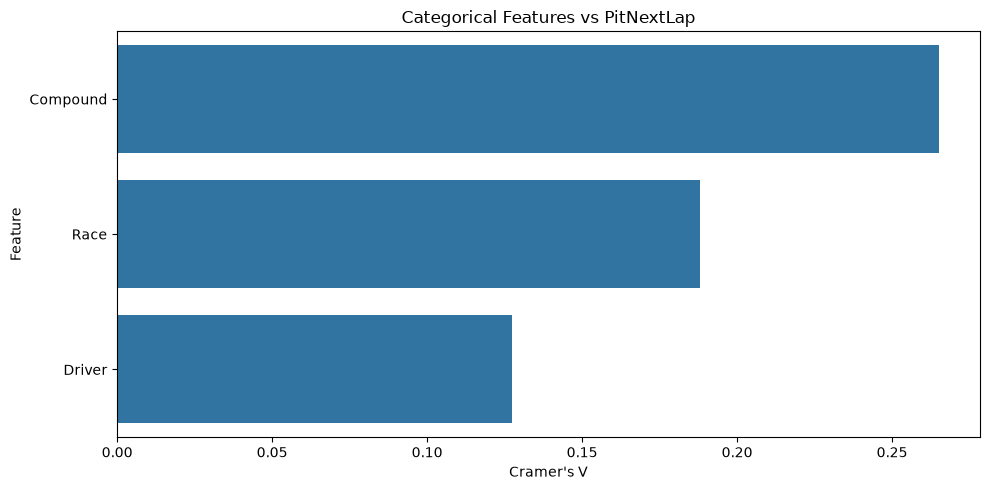

In [91]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=obj_categorical_metrics,
    x="Cramer's V",
    y="Feature"
)

plt.title("Categorical Features vs PitNextLap")
plt.xlabel("Cramer's V")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [3]:
Race=df_train['Race'].value_counts().to_frame()
Race.reset_index()

,Race,count
0,Dutch Grand Prix,24462
1,Mexico City Grand Prix,23672
2,Pre-Season Testing,22492
3,Hungarian Grand Prix,22481
4,Monaco Grand Prix,21539
5,Canadian Grand Prix,21416
6,Austrian Grand Prix,21223
7,Spanish Grand Prix,20483
8,Italian Grand Prix,19854
9,Bahrain Grand Prix,19535


In [11]:
from feature_engineering import *

df_train_fe =set_fe(df_train.copy())
df_train_merged_fe =set_fe(df_train_merged.copy())
df_test_fe =set_fe(df_test.copy())

In [7]:
print(df_train_fe.head(5))

   id Driver Compound                   Race  Year  PitStop  LapNumber  Stint  \
0   0   D109     HARD    Canadian Grand Prix  2022        0         50      2   
1   1   D086     HARD       Dutch Grand Prix  2025        1         27      2   
2   2    ZON     HARD    Austrian Grand Prix  2022        0         59      3   
3   3    SPE   MEDIUM     Pre-Season Testing  2023        0          2      1   
4   4   D019     HARD  Azerbaijan Grand Prix  2022        1         26      3   

   TyreLife  Position  ...  Position_Change  PitNextLap  MaxTireLife  \
0      39.0         8  ...              5.0         1.0           55   
1       7.0         4  ...             -3.0         0.0           55   
2      22.0        13  ...              3.0         1.0           55   
3       2.0         7  ...              0.0         0.0           40   
4       6.0         2  ...              3.0         0.0           55   

   TireRemainingLife  TireAgePct  TireRemainingPct  RaceLaps  LapsRemaining  \
0

In [8]:
print(df_train.head(5))

   id Driver Compound                   Race  Year  PitStop  LapNumber  Stint  \
0   0   D109     HARD    Canadian Grand Prix  2022        0         50      2   
1   1   D086     HARD       Dutch Grand Prix  2025        1         27      2   
2   2    ZON     HARD    Austrian Grand Prix  2022        0         59      3   
3   3    SPE   MEDIUM     Pre-Season Testing  2023        0          2      1   
4   4   D019     HARD  Azerbaijan Grand Prix  2022        1         26      3   

   TyreLife  Position  LapTime (s)  LapTime_Delta  Cumulative_Degradation  \
0      39.0         8       78.491         -7.564                  21.019   
1       7.0         4       75.095        -32.617                -223.207   
2      22.0        13       70.945         -7.540                -100.529   
3       2.0         7       94.361         -7.324                  -7.324   
4       6.0         2      107.878          8.965                 -14.139   

   RaceProgress  Position_Change  PitNextLap  
0  

In [20]:
df_train_fe[["Stint","Year","Compound","TyreLife"]].head()

,Stint,Year,Compound,TyreLife
0,2,2022,HARD,39.0
1,2,2025,HARD,7.0
2,3,2022,HARD,22.0
3,1,2023,MEDIUM,2.0
4,3,2022,HARD,6.0


In [13]:
# Test
df_train_fe[["Stint","Year","Compound","TyreLife","LapTime_Delta","Race","LapNumber","RaceProgress","Cumulative_Degradation"]].head()

,Stint,Year,Compound,TyreLife,LapTime_Delta,Race,LapNumber,RaceProgress,Cumulative_Degradation
0,2,2022,HARD,39.0,-7.564,Canadian Grand Prix,50,0.714286,21.019
1,2,2025,HARD,7.0,-32.617,Dutch Grand Prix,27,0.346154,-223.207
2,3,2022,HARD,22.0,-7.540,Austrian Grand Prix,59,0.819444,-100.529
3,1,2023,MEDIUM,2.0,-7.324,Pre-Season Testing,2,0.076923,-7.324
4,3,2022,HARD,6.0,8.965,Azerbaijan Grand Prix,26,0.361111,-14.139


In [14]:
df_train_merged_fe["Cumulative_Degradation"].describe()

count    540445.000000
mean        -26.435289
std          58.002413
min        -274.564000
25%         -47.611000
50%         -21.067000
75%          -5.918000
max        2412.431000
Name: Cumulative_Degradation, dtype: float64

In [15]:
df_train_merged_fe[[
    "TyreLife",
    "LapTime_Delta",
    "Cumulative_Degradation"
]].corr()

,TyreLife,LapTime_Delta,Cumulative_Degradation
TyreLife,1.000000,0.029938,-0.105629
LapTime_Delta,0.029938,1.000000,0.115367
Cumulative_Degradation,-0.105629,0.115367,1.000000


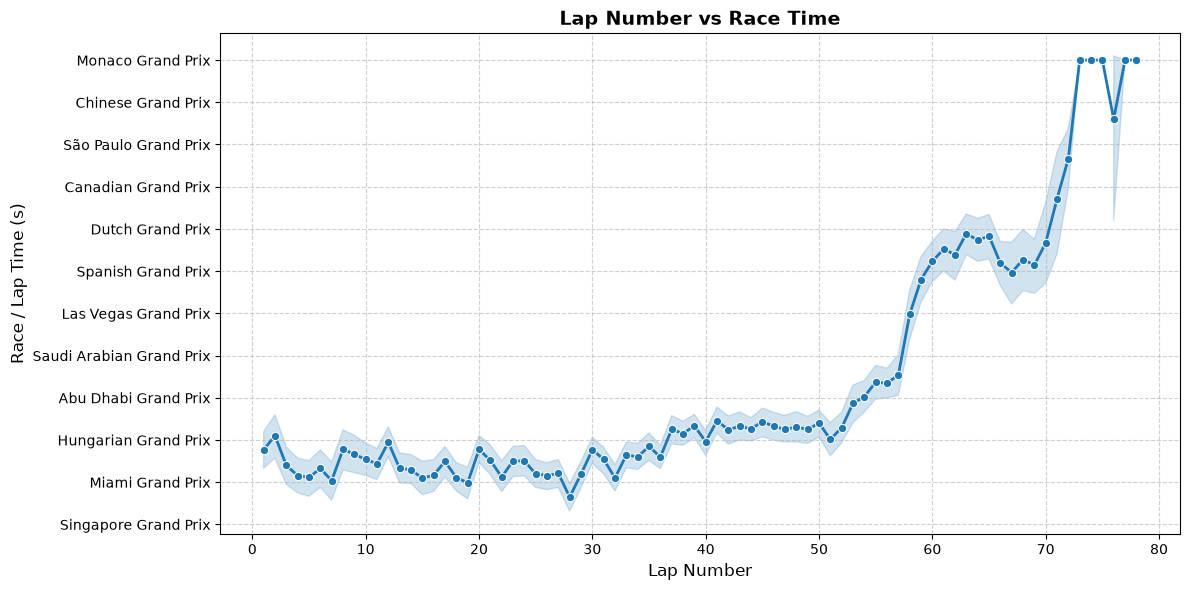

In [22]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_train_merged_fe[df_train_merged_fe["PitNextLap"] == 1], x="LapNumber", y="Race", marker="o", linewidth=2)

plt.title("Lap Number vs Race Time", fontsize=14, fontweight="bold")
plt.xlabel("Lap Number", fontsize=12)
plt.ylabel("Race / Lap Time (s)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# import pandas as pd
# import plotly.express as px
# import matplotlib.pyplot as plt

# 1. Fill nulls across the dataframe (including Stint_Tyre_Std_Dev)
df = df_train_merged_fe.fillna(0)

# 2. Ensure string formatting for text axis combinations
df['Year'] = df['Year'].astype(str)
df['Race'] = df['Race'].astype(str)

# 3. Create combined Year + Race column
df['Year_Race'] = df['Year'] + " - " + df['Race']

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def plot_clean_pit_analysis(df):
    """Generates 3 aggregated, clutter-free visualizations for pit lap data."""
    # 1. Clean & Filter Data
    data = df.fillna(0).copy()
    if "PitNextLap" in data.columns:
        data = data[data["PitNextLap"] == 1]

    # Ensure Year is discrete string
    data["Year"] = data["Year"].astype(int).astype(str)

    fig, axes = plt.subplots(3, 1, figsize=(12, 16))

    # -----------------------------------------------------------------
    # GRAPH 1: Heatmap of Pit Density (Year vs 5-Lap Ranges)
    # -----------------------------------------------------------------
    max_lap = int(data["LapNumber"].max()) if not data.empty else 70
    bins = list(range(0, max_lap + 5, 5))
    labels = [f"Laps {b}-{b+5}" for b in bins[:-1]]

    data["Lap_Range"] = pd.cut(
        data["LapNumber"], bins=bins, labels=labels, right=False
    )
    pivot_df = pd.crosstab(data["Year"], data["Lap_Range"])

    sns.heatmap(
        pivot_df,
        ax=axes[0],
        cmap="YlOrRd",
        annot=True,
        fmt="d",
        cbar_kws={"label": "Pit Stop Count"},
    )
    axes[0].set_title(
        "1. Pit Stop Density Heatmap (Year vs Lap Range)",
        fontweight="bold",
        fontsize=12,
    )
    axes[0].set_xlabel("Lap Range")
    axes[0].set_ylabel("Year")

    # -----------------------------------------------------------------
    # GRAPH 2: Top 15 Most Common Pit Laps
    # -----------------------------------------------------------------
    top_laps = (
        data["LapNumber"].value_counts().head(15).reset_index()
    )
    top_laps.columns = ["LapNumber", "Count"]
    top_laps = top_laps.sort_values("Count", ascending=True)

    axes[1].barh(
        top_laps["LapNumber"].astype(str),
        top_laps["Count"],
        color="#3498db",
        edgecolor="black",
    )
    axes[1].set_title(
        "2. Top 15 Most Frequent Pit Laps Overall",
        fontweight="bold",
        fontsize=12,
    )
    axes[1].set_xlabel("Number of Pit Stops")
    axes[1].set_ylabel("Lap Number")
    axes[1].grid(axis="x", linestyle="--", alpha=0.5)

    # -----------------------------------------------------------------
    # GRAPH 3: Boxplot of Pit Stop Ranges per Year
    # -----------------------------------------------------------------
    sns.boxplot(
        data=data,
        x="Year",
        y="LapNumber",
        ax=axes[2],
        palette="Blues",
        showmeans=True,
    )
    axes[2].set_title(
        "3. Pit Stop Lap Distribution by Year (Median & Spread)",
        fontweight="bold",
        fontsize=12,
    )
    axes[2].set_xlabel("Year")
    axes[2].set_ylabel("Lap Number")
    axes[2].grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


# Run the clean graphs
# plot_clean_pit_analysis(df)

C:\Users\Admin\AppData\Local\Temp\ipykernel_18728\1223047911.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


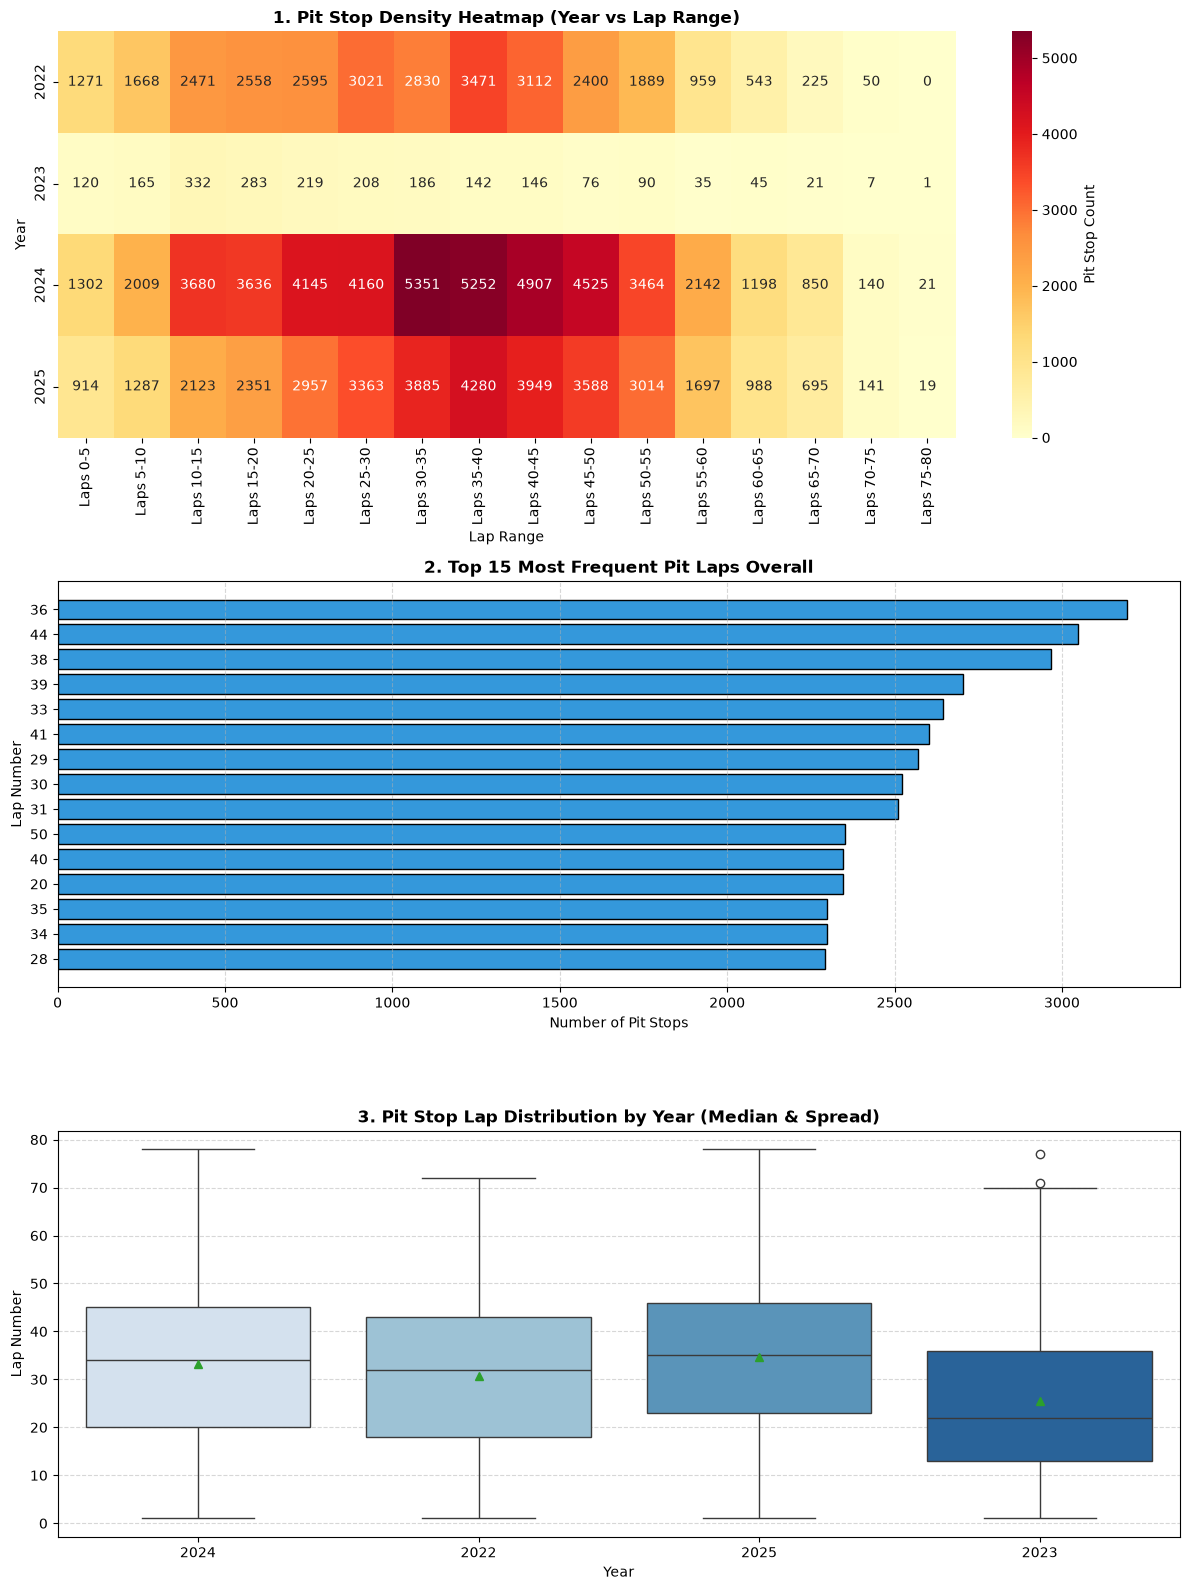

In [41]:
plot_clean_pit_analysis(df_train_merged_fe)

C:\Users\Admin\AppData\Local\Temp\ipykernel_18728\1076111215.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


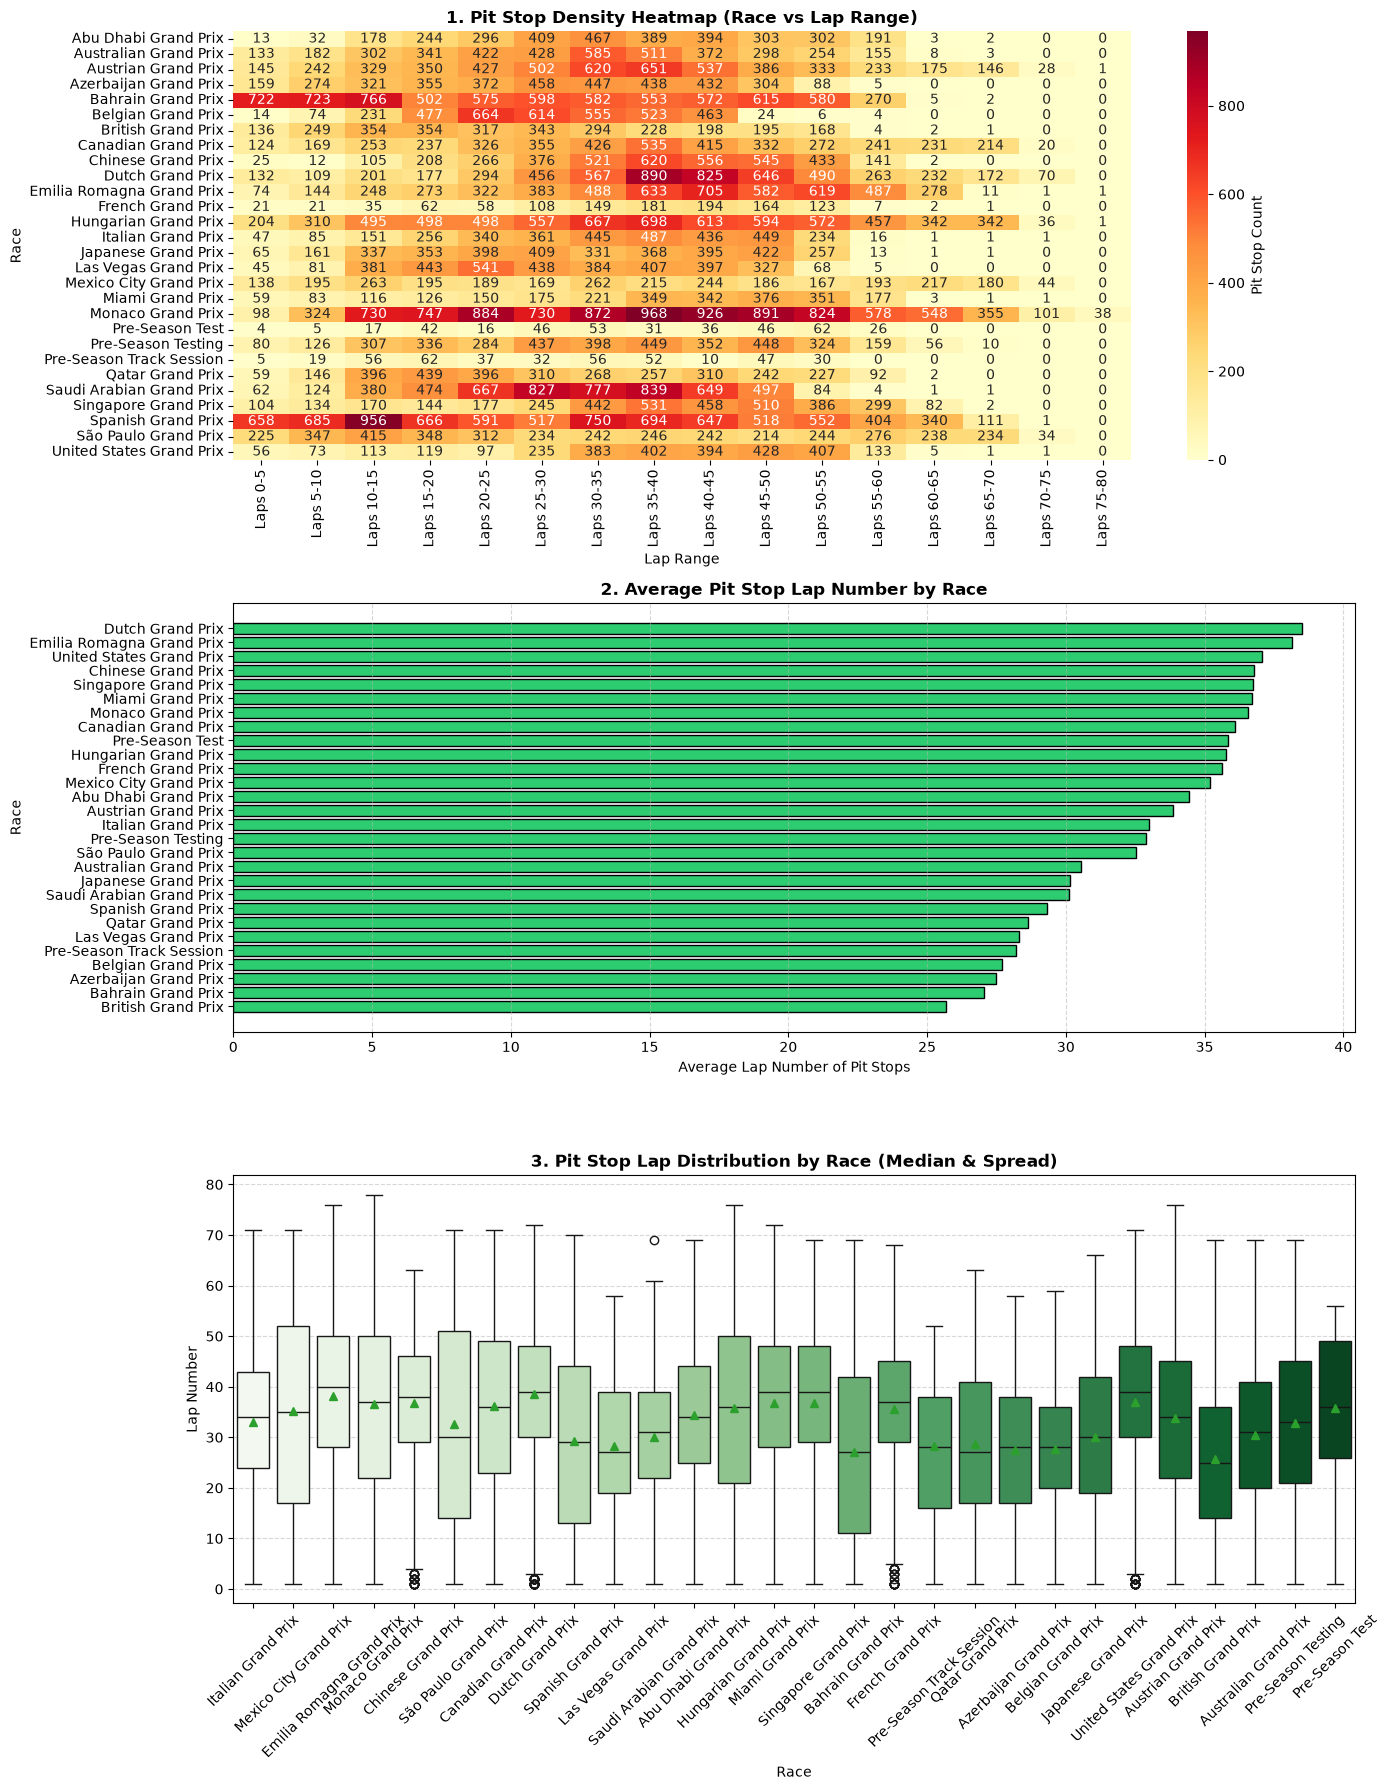

In [42]:

def plot_clean_race_pit_analysis(df):
    """Generates 3 aggregated, clutter-free pit lap visualizations grouped by Race."""
    # 1. Clean & Filter Data
    data = df.fillna(0).copy()
    if "PitNextLap" in data.columns:
        data = data[data["PitNextLap"] == 1]

    data["Race"] = data["Race"].astype(str)

    fig, axes = plt.subplots(3, 1, figsize=(14, 18))

    # -----------------------------------------------------------------
    # GRAPH 1: Heatmap of Pit Density (Race vs 5-Lap Ranges)
    # -----------------------------------------------------------------
    max_lap = int(data["LapNumber"].max()) if not data.empty else 70
    bins = list(range(0, max_lap + 5, 5))
    labels = [f"Laps {b}-{b+5}" for b in bins[:-1]]

    data["Lap_Range"] = pd.cut(
        data["LapNumber"], bins=bins, labels=labels, right=False
    )
    pivot_df = pd.crosstab(data["Race"], data["Lap_Range"])

    sns.heatmap(
        pivot_df,
        ax=axes[0],
        cmap="YlOrRd",
        annot=True,
        fmt="d",
        cbar_kws={"label": "Pit Stop Count"},
    )
    axes[0].set_title(
        "1. Pit Stop Density Heatmap (Race vs Lap Range)",
        fontweight="bold",
        fontsize=12,
    )
    axes[0].set_xlabel("Lap Range")
    axes[0].set_ylabel("Race")

    # -----------------------------------------------------------------
    # GRAPH 2: Average Pit Stop Lap Number by Race
    # -----------------------------------------------------------------
    race_avg_pit = (
        data.groupby("Race")["LapNumber"]
        .mean()
        .reset_index()
        .sort_values("LapNumber", ascending=True)
    )

    axes[1].barh(
        race_avg_pit["Race"],
        race_avg_pit["LapNumber"],
        color="#2ecc71",
        edgecolor="black",
    )
    axes[1].set_title(
        "2. Average Pit Stop Lap Number by Race",
        fontweight="bold",
        fontsize=12,
    )
    axes[1].set_xlabel("Average Lap Number of Pit Stops")
    axes[1].set_ylabel("Race")
    axes[1].grid(axis="x", linestyle="--", alpha=0.5)

    # -----------------------------------------------------------------
    # GRAPH 3: Boxplot of Pit Stop Lap Distribution by Race
    # -----------------------------------------------------------------
    sns.boxplot(
        data=data,
        x="Race",
        y="LapNumber",
        ax=axes[2],
        palette="Greens",
        showmeans=True,
    )
    axes[2].set_title(
        "3. Pit Stop Lap Distribution by Race (Median & Spread)",
        fontweight="bold",
        fontsize=12,
    )
    axes[2].set_xlabel("Race")
    axes[2].set_ylabel("Lap Number")
    axes[2].tick_params(axis="x", rotation=45)
    axes[2].grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


# Run the clean race-focused analysis
plot_clean_race_pit_analysis(df)

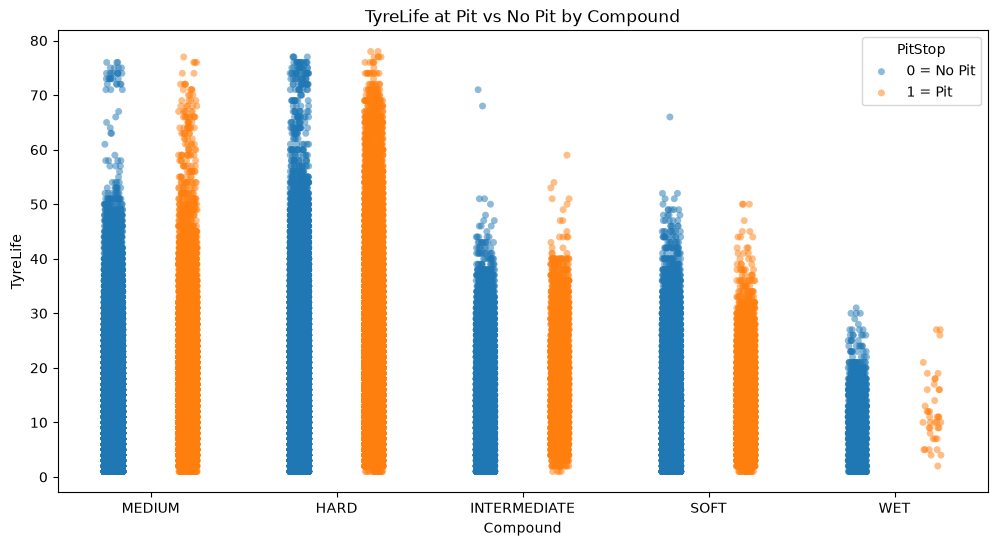

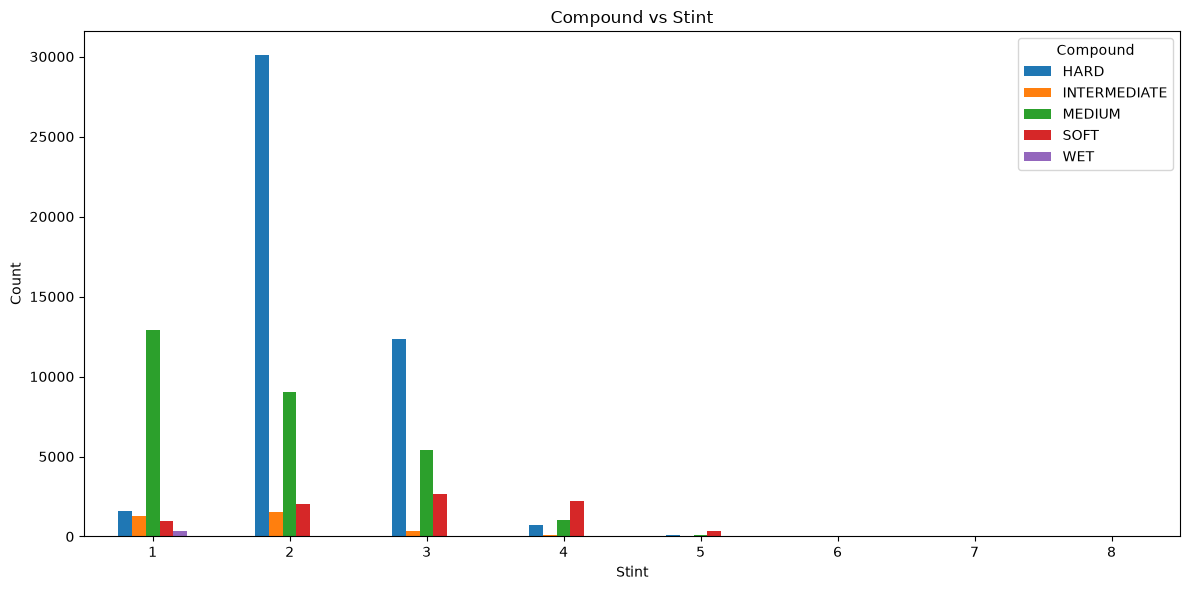

In [15]:
def stint_vs_compound_stint(df):
    stint_counts = (
        df[df["PitStop"]==1].groupby(['Compound', 'Stint'])
        .size()
        .reset_index(name='Count')
    )

    stint_pivot = stint_counts.pivot(
        index='Stint',
        columns='Compound',
        values='Count'
    ).fillna(0)

    stint_pivot.plot(kind='bar', figsize=(12, 6))

    plt.title('Compound vs Stint')
    plt.xlabel('Stint')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.legend(title='Compound')
    plt.tight_layout()
    plt.show()

stint_vs_compound_stint(df_train_merged)

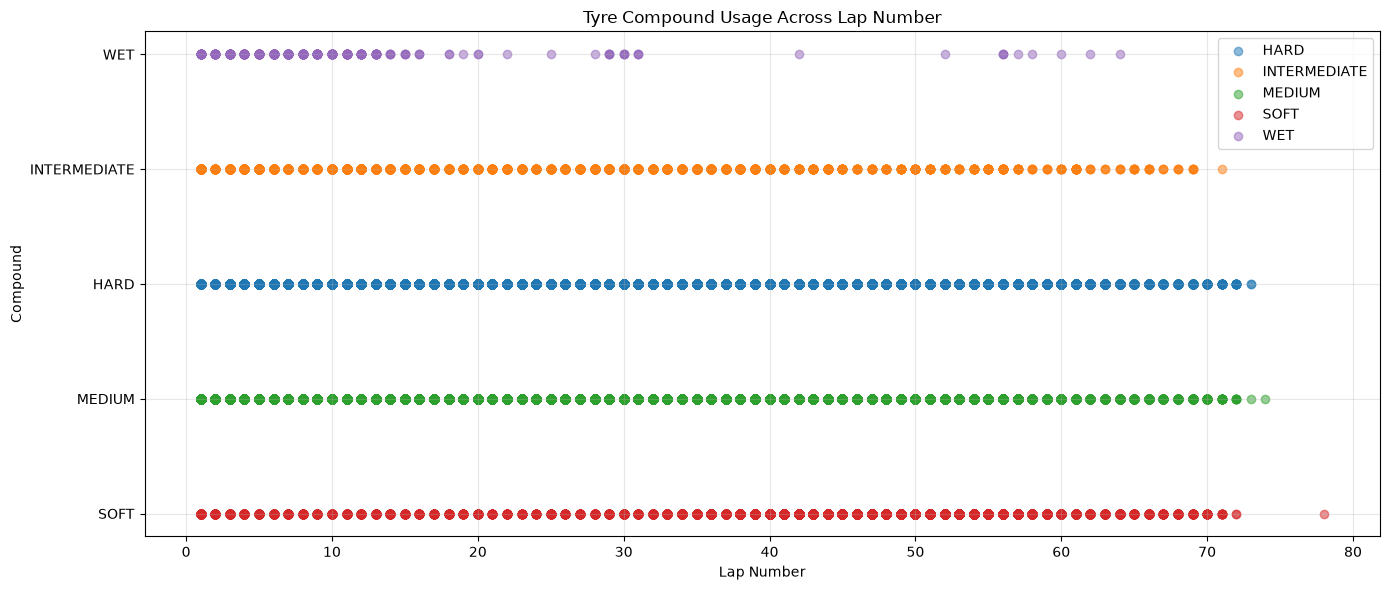

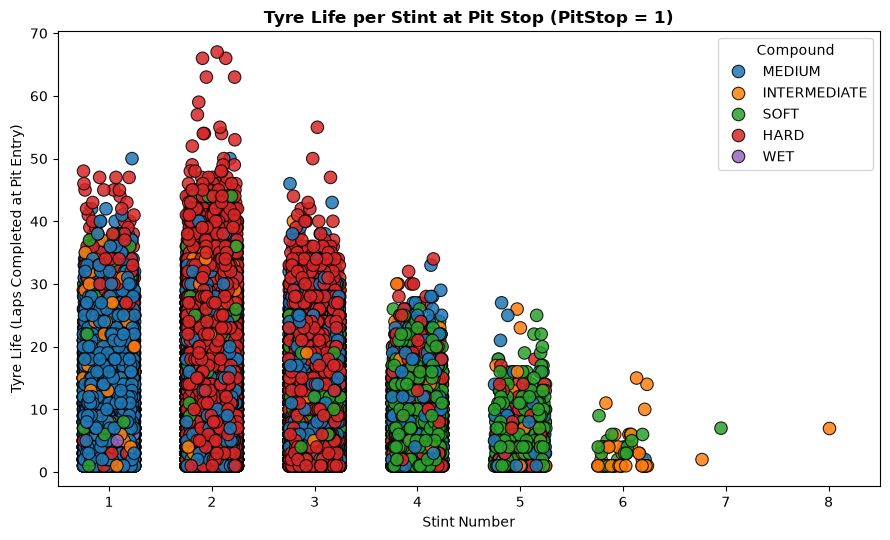

In [23]:

def get_pit_stop_tyre_life(df: pd.DataFrame) -> pd.DataFrame:


    # Filter data exclusively for pit stop laps
    pit_stops = df[df['PitStop'] == 1]

    # Visualizing Stint vs Tyre Life as a Dot Graph
    plt.figure(figsize=(9, 5.5))
    sns.stripplot(
        data=pit_stops, 
        x='Stint', 
        y='TyreLife', 
        hue='Compound',
        size=9, 
        jitter=0.25, 
        alpha=0.85,
        edgecolor='black',
        linewidth=0.8
    )

    plt.title('Tyre Life per Stint at Pit Stop (PitStop = 1)', fontweight='bold', fontsize=12)
    plt.xlabel('Stint Number', fontsize=10)
    plt.ylabel('Tyre Life (Laps Completed at Pit Entry)', fontsize=10)
    plt.legend(title='Compound')
    plt.tight_layout()
    plt.show()
get_pit_stop_tyre_life(df_train_merged)

In [24]:
df_train_merged[df_train_merged["PitStop"]==1]["TyreLife"].value_counts()

TyreLife
1.0     6745
4.0     5531
3.0     5530
2.0     5366
5.0     4823
6.0     4796
7.0     4233
8.0     4072
9.0     3725
10.0    3587
12.0    3470
11.0    3378
13.0    2912
14.0    2801
15.0    2446
16.0    2393
18.0    2095
17.0    2011
20.0    1746
19.0    1707
21.0    1491
22.0    1441
23.0    1300
24.0    1231
25.0    1024
26.0     851
27.0     752
28.0     709
29.0     540
30.0     529
31.0     406
32.0     311
33.0     275
34.0     217
35.0     172
36.0     152
38.0      97
37.0      92
40.0      69
39.0      68
41.0      44
42.0      39
44.0      22
43.0      16
45.0      13
47.0       9
46.0       9
48.0       5
50.0       4
49.0       3
54.0       3
63.0       2
66.0       2
55.0       2
52.0       1
59.0       1
53.0       1
67.0       1
57.0       1
Name: count, dtype: int64

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_mean_tyrelife_by_compound(df: pd.DataFrame, pit_stop_only: bool = True, save_path: str = None) -> pd.DataFrame:
    """
    Calculates mean TyreLife per Compound and plots a bar chart with numeric value labels.
    
    Parameters:
    ----------
    df : pd.DataFrame
        Input DataFrame containing LapNumber, PitStop, Compound, and optionally TyreLife.
    pit_stop_only : bool, default True
        If True, filters for laps where PitStop == 1.
    save_path : str, optional
        Path to save the generated figure.

    Returns:
    -------
    pd.DataFrame
        Aggregated DataFrame with Compound and Mean_TyreLife values.
    """
    df_processed = df.copy()
    
    # Calculate TyreLife if not present
    if 'TyreLife' not in df_processed.columns:
        df_processed = df_processed.sort_values(by=['Year', 'Race', 'Driver', 'LapNumber'])
        df_processed['PrevPit'] = df_processed.groupby(['Year', 'Race', 'Driver'])['PitStop'].shift(1, fill_value=0)
        df_processed['Stint'] = df_processed.groupby(['Year', 'Race', 'Driver'])['PrevPit'].cumsum() + 1
        df_processed['StintStartLap'] = df_processed.groupby(['Year', 'Race', 'Driver', 'Stint'])['LapNumber'].transform('min')
        df_processed['TyreLife'] = df_processed['LapNumber'] - df_processed['StintStartLap'] + 1

    # Filter for pit stops
    if pit_stop_only and 'PitStop' in df_processed.columns:
        df_processed = df_processed[df_processed['PitStop'] == 1]
        
    # Calculate Mean
    mean_df = (
        df_processed.groupby('Compound', as_index=False)['TyreLife']
        .mean()
        .rename(columns={'TyreLife': 'Mean_TyreLife'})
    )
    mean_df['Mean_TyreLife'] = mean_df['Mean_TyreLife'].round(1)
    
    # Plotting
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(7, 4.5))
    
    
    ax = sns.barplot(
        data=mean_df,
        x='Compound',
        y='Mean_TyreLife',
        edgecolor='black',
        width=0.4
    )
    
    # Add data labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f'{height:.1f} Laps',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=10, fontweight='bold', xytext=(0, 4),
                textcoords='offset points'
            )

    plt.title('Mean Tyre Life by Compound at Pit Stop (PitStop = 1)', fontweight='bold', fontsize=12, pad=12)
    plt.xlabel('Tyre Compound', fontsize=10)
    plt.ylabel('Mean Tyre Life (Laps)', fontsize=10)
    plt.ylim(0, mean_df['Mean_TyreLife'].max() + 8)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()
    
    return mean_df

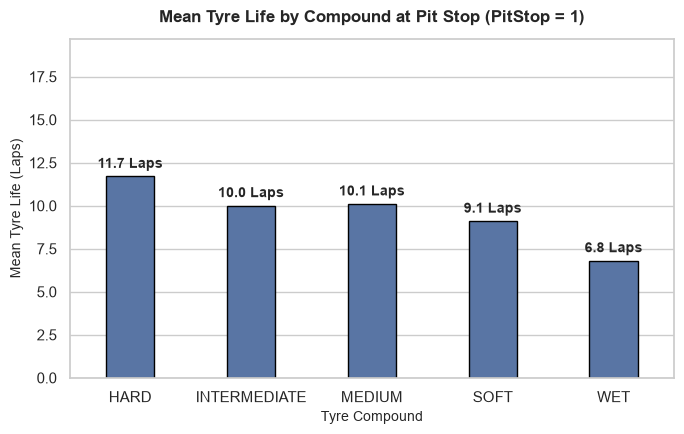

,Compound,Mean_TyreLife
0,HARD,11.7
1,INTERMEDIATE,10.0
2,MEDIUM,10.1
3,SOFT,9.1
4,WET,6.8


In [32]:
plot_mean_tyrelife_by_compound(df_train_merged)